# **Hometask 1. Part 1/3: $\beta$-VAE+NF (18 points)**


## **Notebook Roadmap: Flow-Augmented beta-VAE (18 Points)**

This notebook focuses on building a generative pipeline using a **Vision Transformer (ViT)** backbone for the beta-VAE, followed by a **Real-NVP** Normalizing Flow to refine the latent space manifold.

### **Block 1: ViT and beta-VAE (7 Points)**

Block 1 has two graded parts:

- **ViT stack (4 pts):** patch embedding, transformer encoder blocks, and Gaussian latent heads (mu, logvar, reparameterized z).
- **VAE training (3 pts):** decoder, full VAE forward and loss, beta-weighted ELBO training, and hyperparameter choices as specified.

---

### **Block 2: Real-NVP Latent Flow (10 Points)**

Building a Normalizing Flow to map the complex VAE posterior to a simple Gaussian prior.

- **Flow building blocks (3 pts):** invertible base class, split/merge, and swap layers.
- **Affine coupling (2 pts):** scale-and-shift bijective transformation.
- **Model training (2 pts):** learning the latent distribution via maximum likelihood.
- **Latent visualization (3 pts):** mapped latent geometry and comparison of sampling schemes.

---

### **Block 3: Final Synthesis (1 Point)**

**Concluding remarks (1 pt):** performance analysis, comparison of sampling methods, and architectural insights.

## **General Instructions**
**Code Implementation:**  
- Write code in the specified notebook cells.  
- Use **built-in methods** from libraries (e.g., `sklearn`, `PyTorch`) instead of reinventing the wheel.  
- Ensure reproducibility by fixing random seeds (e.g., `random_state=42`).  

**Discussion & Reporting:**  
- Add a **Markdown cell** after each task to discuss results (if required).  
- Keep explanations concise.  

**Grading Policy**  
- **All-or-nothing scoring** - Full points or zero for each roadmap block or bullet (no partial credit).  
- **Mandatory reproducibility** - Reviewers must obtain identical results when rerunning your notebook.  
- **Output preservation required** - TAs will not rerun notebooks unless potential fraud is detected.  

**Allowed Resources:**  
- Official docs: [Python](https://docs.python.org/3/), [NumPy](https://numpy.org/doc/), [Matplotlib](https://matplotlib.org/), [scikit-learn](https://scikit-learn.org/stable/).  
- External help: Lecture slides, seminars, Google, StackOverflow.  

## **Final Checklist**  
- All code is **well-commented** and reproducible.  
- Discussions are included where required.  
- Notebook runs **end-to-end without errors**.  

**Tip:** Use section headers (like above) in your notebook to improve readability.  


In [120]:
import os
from abc import ABC, abstractmethod

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.decomposition import PCA
from torch.distributions import MultivariateNormal
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Set default font size for all subplot titles
plt.rcParams["axes.titlesize"] = 16

# ViT-$\beta$-VAE

In this notebook you will build a **Variational Autoencoder (VAE)** whose encoder is based on a **Vision Transformer (ViT)**.  
The goal is not only to obtain good reconstructions, but also to carefully analyze and control the structure of the latent space.

After training the $\beta$-VAE, you will typically observe that the aggregated posterior over latents is **not perfectly Gaussian**, even though we impose a Gaussian prior. To improve generation quality, you will then train a **Real-NVP normalizing flow** to learn a transformation from a true standard normal distribution to the learned latent distribution. This allows you to sample more realistic latent codes and enhance generation.

If you encounter posterior collapse during training, you may apply stabilization strategies (e.g., KL annealing or $\beta$ scheduling).

---

## Variational Autoencoder (VAE)

A **Variational Autoencoder (VAE)** (see Kingma & Welling, 2013) is a generative model that learns both how to reconstruct data and how to organize latent variables in a structured probabilistic space.

Unlike a classical autoencoder, a VAE defines a probabilistic encoder and decoder and is trained by maximizing the **Evidence Lower Bound (ELBO)**.

For a detailed and intuitive explanation of VAEs, including derivations and intuitive illustrations, a highly recommended tutorial is available here:

- [**Understanding Variational Autoencoders**](https://lilianweng.github.io/posts/2018-08-12-vae/) by Lilian Weng.

---

## ELBO-based training

We define the encoder (approximate posterior):

$$
{\color{red}{q_{\phi}}}(z|x) = \mathcal{N}\big(z \mid {\color{red}{\mu_{\phi}}}(x), \mathrm{diag}({\color{red}{\sigma_{\phi}}}^2(x))\big),
$$

where ${\color{red}{\mu_{\phi}}}(x)$ and $\log {\color{red}{\sigma_{\phi}}}^2(x)$ are outputs of the encoder network (in our case, a ViT).

We keep a fixed prior:

$$
{\color{purple}{p_Z}}(z) = \mathcal{N}(0, I_d).
$$

The ELBO objective is:

$$
\mathbb{E}_{x \sim p^*(\cdot)} \left[
\underbrace{\mathbb{E}_{z \sim {\color{red}{q_\phi}}(\cdot|x)} 
\log {\color{blue}{p_\theta}}(x|z)}_{\text{reconstruction}}
-
\underbrace{\mathrm{KL}\big({\color{red}{q_\phi}}(\cdot|x)\,\|\,{\color{purple}{p_Z}}(\cdot)\big)}_{\text{prior regularization}}
\right].
$$

The decoder ${\color{blue}{p_\theta}}(x|z)$ is typically modeled as a Gaussian with mean ${\color{blue}{\mu_\theta}}(z)$.  
In practice, the reconstruction term reduces to an MSE-type loss:

$$
\mathbb{E}_{z \sim {\color{red}{q_\phi}}(\cdot|x)}
\frac{\|x - {\color{blue}{\mu_\theta}}(z)\|^2}{2\sigma^2}.
$$

Using the reparameterization trick:

$$
z = {\color{red}{\mu_{\phi}}}(x) + {\color{red}{\sigma_{\phi}}}(x) \odot \xi,
\quad \xi \sim \mathcal{N}(0, I_d),
$$

we obtain a differentiable objective.

The KL term has closed form:

$$
\mathrm{KL}\big({\color{red}{q_\phi}}(\cdot|x)\,\|\,{\color{purple}{p_Z}}(\cdot)\big)
=
\frac{1}{2} \sum_{i=1}^D
\left[
{\color{red}{\mu_{\phi,i}}}(x)^2
+
{\color{red}{\sigma_{\phi,i}}}^2(x)
-
\log {\color{red}{\sigma_{\phi,i}}}^2(x)
\right]
+ \text{const}.
$$

In a $\beta$-VAE (Higgins et al., 2017), we modify the objective:

$$
\mathcal{L}_{\beta\text{-VAE}}
=
\text{Reconstruction}
-
\beta \cdot \mathrm{KL}.
$$

The parameter $\beta$ controls the trade-off between reconstruction quality and latent regularization.

---

## Vision Transformer (ViT)

The **Vision Transformer (ViT)** (Dosovitskiy et al., 2020) processes an image by:

1. Splitting it into fixed-size patches,
2. Embedding each patch into a vector,
3. Applying multi-head self-attention to model global interactions.

Unlike CNNs, ViT captures long-range dependencies directly through attention.

In this task, the ViT replaces the standard CNN encoder and outputs the latent parameters ${\color{red}{\mu_{\phi}}}(x)$ and $\log {\color{red}{\sigma_{\phi}}}^2(x)$.

---

## Latent mismatch and Normalizing Flows

Even though we enforce a Gaussian prior ${\color{purple}{p_Z}}(z)$, the **aggregated posterior**

$$
{\color{red}{q_\phi}}(z) = \mathbb{E}_{x} {\color{red}{q_\phi}}(z|x)
$$

is often **not exactly Gaussian** in practice.

To address this, you will train a **Real-NVP** normalizing flow (Dinh et al., 2017) that learns a bijective map:

$$
u \sim \mathcal{N}(0, \mathbb{I})
\quad \longrightarrow \quad
z \sim {\color{red}{q_\phi}}(z).
$$

After training the flow:

1. Sample $u \sim \mathcal{N}(0, I_d)$,
2. Transform it via the flow to obtain $z$,
3. Decode $\hat{x} = {\color{blue}{\mu_\theta}}(z)$.

This typically improves generation quality compared to directly sampling $z \sim {\color{purple}{p_Z}}(z)$.

---

## References

- Kingma & Welling, [*Auto-Encoding Variational Bayes*](https://arxiv.org/abs/1312.6114), 2013
- Higgins et al., [*beta-VAE: Learning Basic Visual Concepts with a Constrained Variational Framework*](https://openreview.net/forum?id=Sy2fzU9gl), 2017  
- Vaswani et al., [*Attention Is All You Need*](https://arxiv.org/abs/1706.03762), 2017  
- Dosovitskiy et al., [*An Image is Worth 16x16 Words*](https://arxiv.org/abs/2010.11929), 2020  
- Dinh et al., [*Density Estimation using Real NVP*](https://arxiv.org/abs/1605.08803), 2017  

## Block 1: ViT beta-VAE - setup and components

We begin by downloading the MNIST dataset, which will be used for training the model.

In [121]:
# Downloading MNIST dataset
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)  # shape: [60000, 1, 28, 28]
test_dataset = datasets.MNIST("./data", train=False, download=True, transform=transform)  # shape: [10000, 1, 28, 28]

### Patch embedding

Here we implement the patch embedding. The input image is first split into fixed-size patches. Each patch is linearly embedded into a vector representation, and positional embeddings are added to preserve spatial information. Below is a visual illustration of the encoder.

<div style="text-align:center;">
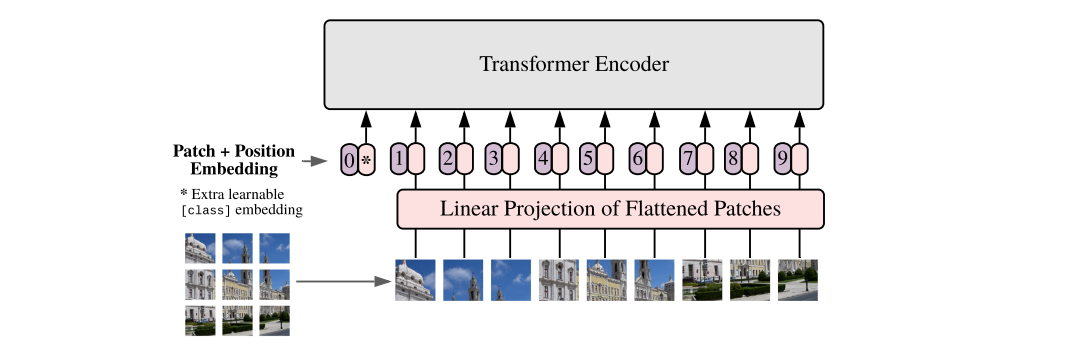
</div>

In [122]:
IMAGE_SIZE = 28
CHANNELS = 1
INPUT_SHAPE = (CHANNELS, IMAGE_SIZE, IMAGE_SIZE)

LATENT_DIM = 64
PATCH_SIZE = 4
assert IMAGE_SIZE % PATCH_SIZE == 0, "Patch size must be a divisor of the image size."
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [123]:
class PatchEmbedding(nn.Module):
    """
    Patch embedding layer: extracts image patches, projects them into an embedding
    space, and adds positional embeddings.
    """

    def __init__(
        self,
        patch_size: int,
        num_patches: int,
        embed_dim: int,
        in_channels: int,
    ):
        super().__init__()
        self.patch_size = patch_size
        self.num_patches = num_patches

        # TODO: PatchEmbedding - implement __init__ and forward: map (B,C,H,W) to patch tokens
        # (B, num_patches, embed_dim) with positional embeddings; return those tokens and raw
        # patch vectors (B, num_patches, C * patch_size**2) as the second output.
        self.unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
        self.projection = nn.Linear(in_channels * patch_size * patch_size, embed_dim)
        self.position_embedding = nn.Embedding(num_patches, embed_dim)

    def forward(self, images: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass: compute patch embeddings with positional information

        Args:
            images: Tensor of shape (B, C, H, W)
        Returns:
            embeddings with positional info: (B, num_patches, embed_dim)
            raw flattened patches: (B, num_patches, C*p*p)
        """

        _, _, H, W = images.shape
        p = self.patch_size

        assert H % p == 0 and W % p == 0, "Image dimensions must be divisible by patch size"

        patches = self.unfold(images)              # (B, C*p*p, num_patches)
        patches = patches.transpose(1, 2)          # (B, num_patches, C*p*p)
        embeddings = self.projection(patches)      # (B, num_patches, embed_dim)

        positions = torch.arange(self.num_patches, device=images.device)  # (num_patches,)
        pos_embed = self.position_embedding(positions)                     # (num_patches, embed_dim)

        return embeddings + pos_embed.unsqueeze(0), patches


Let's take a look at the patches extracted and embedded by the `PatchEmbedding`.

In [124]:
patch_embedder = PatchEmbedding(PATCH_SIZE, NUM_PATCHES, LATENT_DIM, CHANNELS)

In [125]:
def show_patch_embedding(
    image: torch.Tensor,
    patch_embedder: PatchEmbedding,
    channels: int = CHANNELS,
    patch_size: int = PATCH_SIZE,
    num_patches: int = NUM_PATCHES,
    latent_dim: int = LATENT_DIM,
):
    """
    Visualizes image patches and patch embeddings color-coded by pixel sums.

    Args:
        image: torch.Tensor of shape (C, H, W) or (1, C, H, W)
        patch_embedder: trained PatchEmbedding module
    """

    # ---- Ensure batch dimension ----
    if image.ndim == 2:
        image = image.unsqueeze(0).unsqueeze(0)
    elif image.ndim == 3:
        image = image.unsqueeze(0)

    # ---- Extract patches ----
    with torch.no_grad():
        embeddings, patches = patch_embedder(image)

    patches = patches.squeeze(0).view(num_patches, channels, patch_size, patch_size)
    embeddings = embeddings.squeeze(0).cpu().numpy()

    # ---- Compute colors based on pixel sums ----
    pixel_sums = patches.sum(dim=(1, 2, 3))
    mask = pixel_sums < pixel_sums.mean()

    # ---- Convert grayscale to RGB if needed ----
    if channels == 1:
        patches = patches.repeat(1, 3, 1, 1)

    # ---- Mark bottom-right pixel ----
    patches = patches.clone()
    patches[mask, :, -1, -1] = torch.tensor([1, 0, 0], dtype=patches.dtype, device=patches.device)  # Red
    patches[~mask, :, -1, -1] = torch.tensor([0, 0, 1], dtype=patches.dtype, device=patches.device)  # Blue

    # ---- Create grid using make_grid ----
    n = int(np.sqrt(num_patches))
    grid = make_grid(patches.cpu(), nrow=n, padding=1, pad_value=1.0, normalize=False)
    grid = grid.permute(1, 2, 0).numpy()

    # ---- Plot ----
    fig = plt.figure(figsize=(10, 5))

    # Patch grid
    ax = fig.add_subplot(1, 2, 1)
    ax.imshow(grid)
    ax.set_title(f"{num_patches} extracted {patch_size}x{patch_size} patches")
    ax.axis("off")

    # ---- Plot patch embeddings (PCA if needed) ----
    assert latent_dim >= 3, "latent_dim must be >= 3 for 3D visualization"

    if latent_dim > 3:
        pca = PCA(n_components=3)
        encoded_3d = pca.fit_transform(embeddings)
    else:
        encoded_3d = embeddings[:, :3]

    x, y, z = encoded_3d.T

    # Create color array for scatter
    point_colors = np.zeros((num_patches, 3))
    point_colors[mask.cpu().numpy()] = [1, 0, 0]
    point_colors[~mask.cpu().numpy()] = [0, 0, 1]

    ax = fig.add_subplot(1, 2, 2, projection="3d")
    ax.set_title(f"{num_patches} patch embeddings")
    ax.scatter(x, y, z, c=point_colors, s=35, alpha=0.7)

    plt.tight_layout()
    plt.show()

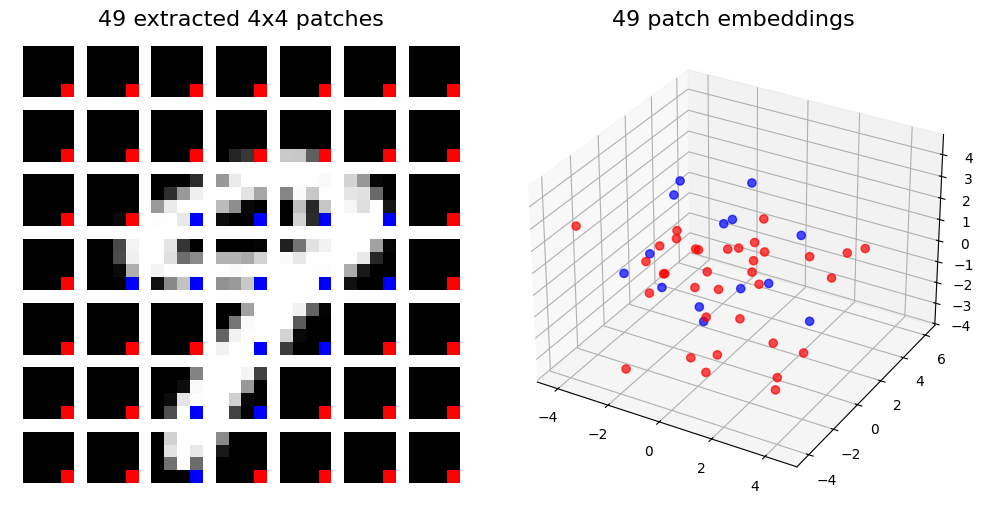

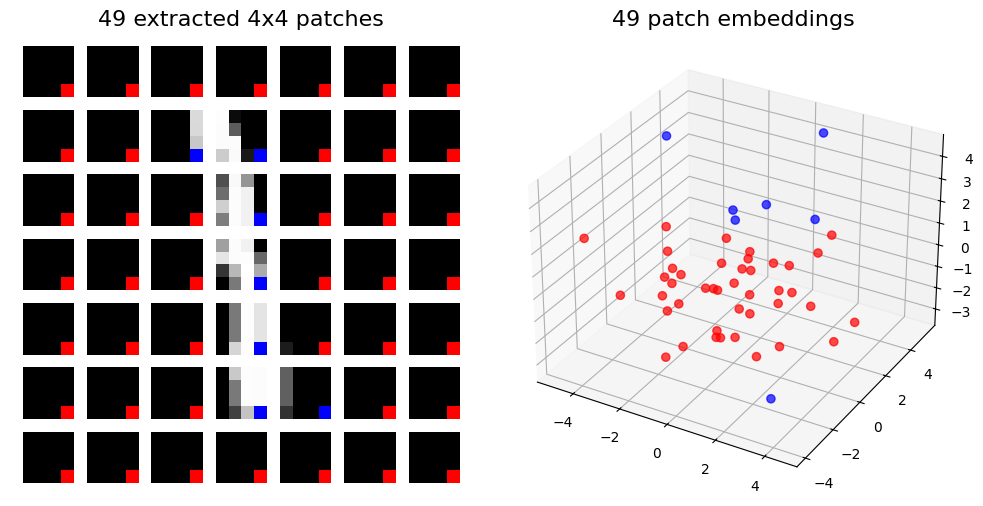

In [126]:
show_patch_embedding(test_dataset[9][0], patch_embedder)
show_patch_embedding(test_dataset[29][0], patch_embedder)

### ViT encoder and VAE bottleneck

Implement the ViT backbone that turns an image into patch tokens, then into Gaussian **mu**, **logvar**, and a reparameterized latent **z**. The notebook introduction above covers the ELBO, the reparameterization trick, beta weighting, why the aggregate posterior need not be Gaussian, and how Real-NVP fits in.

The figure below illustrates the architecture of the ViT encoder.


<div style="text-align:center;">
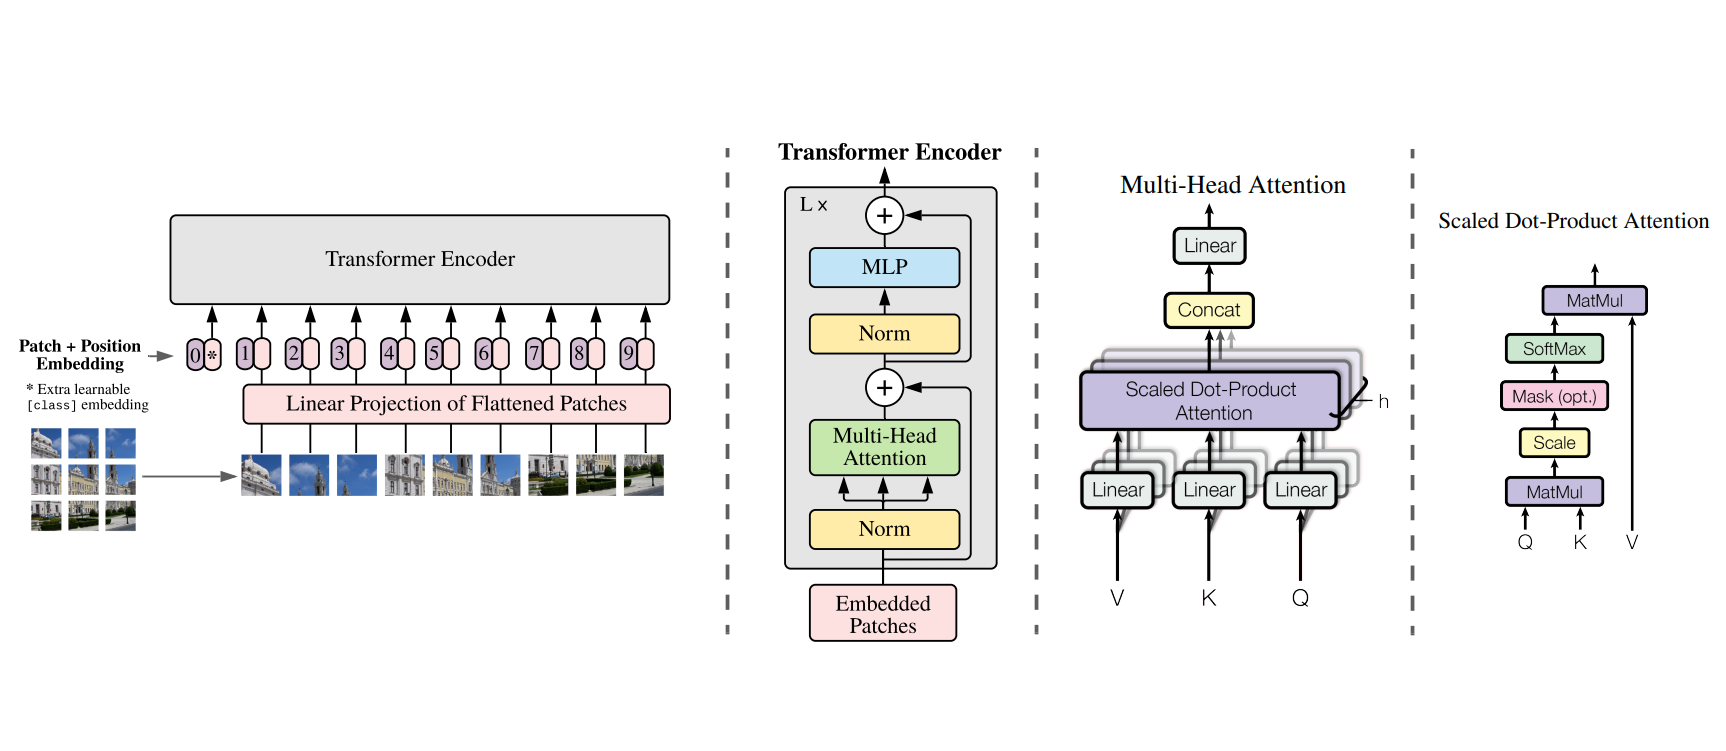
</div>

In [127]:
NUM_HEADS = 4  # h on visual scheme
assert (
    LATENT_DIM % NUM_HEADS == 0
), "embed_dim must be divisible by NUM_HEADS (each head has dimension embed_dim // NUM_HEADS)"
TRANSFORMER_LAYERS = 8  # L on visual scheme

FFN_HIDDEN_SIZES = [LATENT_DIM * 2, LATENT_DIM]

MLP_HEAD_UNITS = [2048, 1024]

In [128]:
class MLPBlock(nn.Module):
    def __init__(self, input_dim: int, ffn_hidden_sizes: list[int], dropout_rate: float = 0.1):
        super().__init__()

        # TODO: MLPBlock - stack Linear -> GELU; use Dropout after hidden layers only (not after the last).
        layers = []

        prev_dim = input_dim
        for i, hidden_size in enumerate(ffn_hidden_sizes):
            layers.append(nn.Linear(prev_dim, hidden_size))
            layers.append(nn.GELU())
            if i < len(ffn_hidden_sizes) - 1:
                layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_size

        self.mlp = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.mlp(x)


In [129]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim: int, num_heads: int, ffn_hidden_sizes: list[int], dropout_rate: float = 0.1):
        super().__init__()

        # TODO: TransformerBlock - pre-norm ViT block (attention residual, then MLP residual); keep (B, num_patches, embed_dim).
        self.norm1 = nn.LayerNorm(embed_dim, eps=1e-6)

        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout_rate,
            kdim=embed_dim,
            vdim=embed_dim,
            batch_first=True,
        )

        self.norm2 = nn.LayerNorm(embed_dim, eps=1e-6)
        self.mlp = MLPBlock(embed_dim, ffn_hidden_sizes, dropout_rate)
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through Transformer block.
        Args:
            x: Tensor of shape (B, num_patches, embed_dim)
        Returns:
            Tensor of the same shape with updated patch embeddings
        """

        x1 = self.norm1(x)
        Q, K, V = x1, x1, x1
        attn_output, _ = self.attn(Q, K, V)
        x2 = x + self.dropout(attn_output)
        x3 = self.norm2(x2)
        x3 = self.mlp(x3)
        x3 = self.dropout(x3)
        out = x2 + x3

        return out


In [130]:
class TransformerEncoder(nn.Module):
    def __init__(
        self,
        patch_size: int,
        num_patches: int,
        embed_dim: int,
        transformer_layers: int,
        num_heads: int,
        ffn_hidden_sizes: list[int],
        in_channels: int = 1,
        dropout_rate: float = 0.1,
    ):
        super().__init__()

        # TODO: TransformerEncoder - PatchEmbedding then `transformer_layers` stacked TransformerBlocks.
        self.patch_embedding = PatchEmbedding(patch_size, num_patches, embed_dim, in_channels)
        self.transformer_blocks = nn.ModuleList(
            [TransformerBlock(embed_dim, num_heads, ffn_hidden_sizes, dropout_rate) for _ in range(transformer_layers)]
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass through the Transformer encoder.
        Args:
            x: Tensor of shape (B, C, H, W)
        Returns:
            Tensor of shape (B, num_patches, embed_dim)
        """

        x, _ = self.patch_embedding(x)
        for block in self.transformer_blocks:
            x = block(x)

        return x


In [131]:
# ------------------------------
# VAE Encoder
# ------------------------------
class Encoder(nn.Module):
    """
    ViT-based VAE Encoder.
    Outputs mu, logvar, and z using the reparameterization trick.
    """

    def __init__(
        self,
        transformer_encoder: TransformerEncoder,
        embed_dim: int,
        latent_dim: int,
        num_patches: int,
        dropout_rate: float = 0.1,
    ):
        super().__init__()

        # TODO: Encoder - ViT trunk, LayerNorm+flatten+dropout, Gaussian heads (mu, logvar), reparameterized z.
        self.transformer_encoder = transformer_encoder
        self.flatten = nn.Flatten(start_dim=1)
        self.dropout = nn.Dropout(dropout_rate)
        self.layernorm = nn.LayerNorm(num_patches * embed_dim, eps=1e-6)
        self.mu_layer = nn.Linear(num_patches * embed_dim, latent_dim)
        self.logvar_layer = nn.Linear(num_patches * embed_dim, latent_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.transformer_encoder(x)   # (B, num_patches, embed_dim)
        features = self.flatten(features)         # (B, num_patches * embed_dim)
        features = self.layernorm(features)
        features = self.dropout(features)

        mu = self.mu_layer(features)
        logvar = self.logvar_layer(features)

        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        z = mu + std * eps

        return mu, logvar, z


### VAE decoder

The **decoder** reconstructs an image from a latent vector **z**, essentially reversing the encoding process.  
It learns to map latent representations back into realistic images, ensuring that the **latent space captures meaningful features**.  

When designing the decoder, choose an architecture that balances expressiveness and regularization.  
>  If the decoder is too powerful, the **KL term may collapse to 0**, effectively ignoring the latent space. Think about why this happens and how it affects learning.

> Answer: If the decoder is too powerful, it can reconstruct x without using z, so the model minimizes the KL term by making $q(z|x)$ match the prior, causing posterior collapse and an uninformative latent space.

In [132]:
# ------------------------------
# VAE Decoder
# ------------------------------
class Decoder(nn.Module):
    def __init__(self, latent_dim: int = LATENT_DIM):
        super().__init__()

        # TODO: Decoder - upsampling CNN from latent_dim to image (e.g. linear expand -> conv transpose -> sigmoid).
        self.fc = nn.Linear(latent_dim, 64 * 7 * 7)
        self.conv_transpose1 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)  # 7x7 -> 14x14
        self.conv_transpose2 = nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1)  # 14x14 -> 28x28
        self.conv_out = nn.Conv2d(16, 1, kernel_size=3, stride=1, padding=1)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        x = self.fc(z)
        x = x.view(x.size(0), 64, 7, 7)
        x = F.relu(self.conv_transpose1(x))
        x = F.relu(self.conv_transpose2(x))
        x = torch.sigmoid(self.conv_out(x))
        return x


## ViT-$\beta$-VAE training

Now we will initialize and train the ViT-$\beta$-VAE model.  
To do this, implement the class below that defines the training setup and forward pass.

In [133]:
# ------------------------------
# Full VAE Model
# ------------------------------
class VAE(nn.Module):
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    # TODO: VAE - forward: encode then decode z; compute_loss: MSE reconstruction + kl_weight * KL(q(z|x) || N(0,I)).

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        mu, logvar, z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, mu, logvar

    def compute_loss(self, x: torch.Tensor, kl_weight: float) -> torch.Tensor:
        x_recon, mu, logvar = self.forward(x)

        recon_loss = F.mse_loss(x_recon, x, reduction="mean")

        kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))

        total_loss = recon_loss + kl_weight * kl_loss
        return total_loss, recon_loss, kl_loss

    def training_step(
        self, x: torch.Tensor, optimizer: torch.optim.Optimizer, kl_weight: float = 0.1
    ) -> dict[str, float]:
        optimizer.zero_grad()
        total_loss, recon_loss, kl_loss = self.compute_loss(x, kl_weight)
        total_loss.backward()
        optimizer.step()
        return {"total_loss": total_loss.item(), "reconstruction_loss": recon_loss.item(), "kl_loss": kl_loss.item()}


Choose hyperparameters for training.

In [134]:
BATCH_SIZE = 1024
LR = 3e-4

In [135]:
transformer_encoder = TransformerEncoder(
    PATCH_SIZE, NUM_PATCHES, LATENT_DIM, TRANSFORMER_LAYERS, NUM_HEADS, FFN_HIDDEN_SIZES, CHANNELS
)
encoder = Encoder(
    transformer_encoder=transformer_encoder,
    embed_dim=LATENT_DIM,
    latent_dim=LATENT_DIM,
    num_patches=NUM_PATCHES,
).to(DEVICE)

decoder = Decoder(latent_dim=LATENT_DIM).to(DEVICE)

vae = VAE(encoder, decoder).to(DEVICE)

optimizer = torch.optim.Adam(vae.parameters(), lr=LR)

Ensure that the total number of learnable parameters does not differ drastically between models.

In [136]:
encoder_params = sum(p.numel() for p in encoder.parameters())
decoder_params = sum(p.numel() for p in decoder.parameters())
print(f"Encoder: {encoder_params/1e3:.1f}k, Decoder: {decoder_params/1e3:.1f}k")

Encoder: 679.8k, Decoder: 245.0k


In [137]:
num_cpu = os.cpu_count()

train_dataloader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=num_cpu // 2,
    pin_memory=True,  # important if using GPU
    persistent_workers=True,  # keeps workers alive between epochs
)

test_dataloader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    num_workers=num_cpu // 2,
    pin_memory=True,
    persistent_workers=True,
)

In [138]:
def train_vae(
    vae: VAE,
    train_dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    kl_weights: torch.Tensor,  # 1D tensor or list with length = num_epochs
    device: str = DEVICE,
):
    """
    Args:
        vae: VAE model with .training_step(x, optimizer, kl_weight) method
        train_dataloader: DataLoader
        optimizer: torch optimizer
        kl_weights: iterable of KL weights (one per epoch)
        device: str
    """

    num_epochs = len(kl_weights)
    vae.train()

    for epoch in range(num_epochs):
        kl_weight = kl_weights[epoch]
        total_loss = 0.0
        recon_loss = 0.0
        kl_loss = 0.0

        for x, _ in train_dataloader:
            x = x.to(device)

            loss_dict = vae.training_step(
                x,
                optimizer,
                kl_weight=kl_weight,
            )

            total_loss += loss_dict["total_loss"]
            recon_loss += loss_dict["reconstruction_loss"]
            kl_loss += loss_dict["kl_loss"]

        n_batches = len(train_dataloader)

        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"KL weight: {kl_weight:.4f} | "
            f"Total: {total_loss / n_batches:.4f} | "
            f"Recon: {recon_loss / n_batches:.4f} | "
            f"KL: {kl_loss / n_batches:.4f}"
        )

**Select the hyperparameters.** In this task, the goal is to obtain **good reconstruction** even if the **KL loss is high**, because the latent space is expected to deviate from a standard normal. Later, we will correct this mismatch using a **normalizing flow**.

  

If you notice that the **KL loss decreases sharply during training**, it indicates **posterior collapse**. For now, simply use a **constant KL weight**. Posterior collapse can be addressed later with the **stabilization strategies** described below.

In [139]:
NUM_EPOCHS = 50
KL_WEIGHT = 2e-3

kl_weights = torch.full((NUM_EPOCHS,), KL_WEIGHT)  # choose constant weight during training

In [140]:
train_vae(vae, train_dataloader, optimizer, kl_weights)

Epoch [1/50] | KL weight: 0.0020 | Total: 0.1873 | Recon: 0.1749 | KL: 6.1882
Epoch [2/50] | KL weight: 0.0020 | Total: 0.0833 | Recon: 0.0721 | KL: 5.6074
Epoch [3/50] | KL weight: 0.0020 | Total: 0.0764 | Recon: 0.0656 | KL: 5.4310
Epoch [4/50] | KL weight: 0.0020 | Total: 0.0737 | Recon: 0.0625 | KL: 5.6368
Epoch [5/50] | KL weight: 0.0020 | Total: 0.0717 | Recon: 0.0605 | KL: 5.6064
Epoch [6/50] | KL weight: 0.0020 | Total: 0.0700 | Recon: 0.0590 | KL: 5.4956
Epoch [7/50] | KL weight: 0.0020 | Total: 0.0681 | Recon: 0.0576 | KL: 5.2746
Epoch [8/50] | KL weight: 0.0020 | Total: 0.0660 | Recon: 0.0560 | KL: 4.9750
Epoch [9/50] | KL weight: 0.0020 | Total: 0.0639 | Recon: 0.0546 | KL: 4.6741
Epoch [10/50] | KL weight: 0.0020 | Total: 0.0623 | Recon: 0.0532 | KL: 4.5370
Epoch [11/50] | KL weight: 0.0020 | Total: 0.0608 | Recon: 0.0521 | KL: 4.3501
Epoch [12/50] | KL weight: 0.0020 | Total: 0.0595 | Recon: 0.0509 | KL: 4.3106
Epoch [13/50] | KL weight: 0.0020 | Total: 0.0584 | Recon: 0.

Exception ignored in: Exception ignored in: Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7fc097632b60><function _MultiProcessingDataLoaderIter.__del__ at 0x7fc097632b60><function _MultiProcessingDataLoaderIter.__del__ at 0x7fc097632b60>


Exception ignored in: Traceback (most recent call last):
Traceback (most recent call last):
Traceback (most recent call last):
<function _MultiProcessingDataLoaderIter.__del__ at 0x7fc097632b60>  File "/home/jovyan/chikovani/envs/kandinsky-cuda12.8/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
  File "/home/jovyan/chikovani/envs/kandinsky-cuda12.8/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__

  File "/home/jovyan/chikovani/envs/kandinsky-cuda12.8/lib/python3.12/site-packages/torch/utils/data/dataloader.py", line 1663, in __del__
Traceback (most recent call last):
  File "/home/jovyan/chikovani/envs/kandinsky-cuda12.8/lib/python3.12/site-packages

- With $\beta > 2e-3$ I observed the KL loss to decrease, which caused reconstruction loss to not decrease this much, which resulted in reconstructions to be very blurry

- $\beta = 1e-3$ resulted in reconstructions with too little blur, which does not allow to see improvement in quality for RealNVP, so optimal beta is 2e-3

Let's visualize the latent space.

In [141]:
def show_latent_space(encoder: Encoder, test_loader: DataLoader, device: str = DEVICE):
    """
    Computes latent representations (mu) for the whole test set in batches
    and plots the first 3 dimensions in 3D, color-coded by class labels.

    encoder : TransformerEncoder
        The trained VAE encoder
    test_loader : DataLoader
        PyTorch DataLoader for the test set
    device : str
        Device (CPU/GPU) for computation
    """
    encoder.eval()  # set to evaluation mode
    all_mu = []
    all_logvar = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)
            mu, logvar, _ = encoder(images)

            all_mu.append(mu.cpu())
            all_logvar.append(logvar.cpu())
            all_labels.append(labels.cpu())

    # Concatenate all batches
    mu_np = torch.cat(all_mu, dim=0).numpy()
    logvar_np = torch.cat(all_logvar, dim=0).numpy()
    labels_np = torch.cat(all_labels, dim=0).numpy()

    # Print first 10 entries
    np.set_printoptions(suppress=True)
    print("\mu values :\n\n", np.round(mu_np[:10], 5), ".....")
    print("\nlog_variance values :\n\n", np.round(logvar_np[:10], 5), ".....\n")

    # Plot in 3D
    fig = plt.figure(figsize=(10, 10))
    ax = plt.axes(projection="3d")
    ax.set_title(r"Latent space $\mu$ distribution")

    # ---- PCA to 3D ----
    if mu_np.shape[1] > 3:
        pca = PCA(n_components=3)
        mu_3d = pca.fit_transform(mu_np)
        print(f"Explained variance ratio (first 3 PCs): {pca.explained_variance_ratio_}")
    else:
        mu_3d = mu_np

    # Scatter using first 3 dimensions of mu
    p = ax.scatter(mu_3d[:, 0], mu_3d[:, 1], mu_3d[:, 2], c=labels_np, cmap="tab10", alpha=0.7)

    fig.colorbar(p, ax=ax, shrink=0.6)
    plt.show();

\mu values :

 [[-0.02988  0.16988  0.16619 -0.11294 -0.04123  0.12716  0.10398 -0.1306
   0.03708 -0.0455  -0.00217 -0.01685 -0.03061 -0.8155  -0.01895  0.03212
  -0.07649 -0.24308 -1.76332  0.04469  0.02362 -0.21839 -0.00651  0.03485
  -0.00654  0.32733 -1.4395   0.08336 -0.10324  0.02739 -0.05248  0.08905
   1.83435 -0.21662  0.02625 -0.06464 -0.00814 -0.05056  0.0305   0.123
   0.01065  0.07296  0.03728  0.00559 -0.07013  0.05965  0.03038 -0.14216
   0.04733  0.23235  0.18309 -0.0279   0.05278 -0.13382 -0.08245  0.01578
   0.08412 -0.14944 -0.167    0.06447  0.02005  0.37531 -0.0157  -0.01309]
 [-0.00672 -0.00287  0.12479  0.02585  0.02216 -0.27384  0.04672 -0.0505
  -0.01393 -0.07221 -0.00435  0.00967 -0.18218  0.75816 -0.03262 -0.07945
  -0.10945  0.08856  2.67936  0.07607  0.17869 -0.69213  0.00052  0.24153
  -0.00391  0.21519 -0.36812  0.06625  0.0154   0.08139 -0.22888  0.01495
  -0.71667  0.12694  0.11721  0.03827 -0.02862 -0.21142 -0.0063   0.07531
  -0.08665  0.08198 -0.125

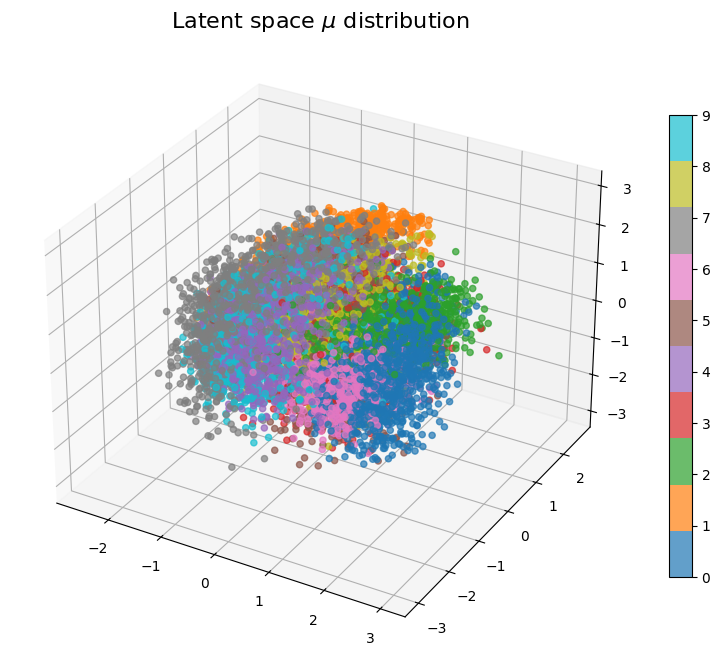

In [142]:
show_latent_space(encoder, test_dataloader)

In [143]:
def show_vae_example(image: torch.Tensor, encoder: Encoder, decoder: Decoder, n: int = 10, device: str = DEVICE):
    """
    Visualizes a single image, its latent distribution, reconstruction, and generated images.

    image: Tensor (C,H,W) or (1,C,H,W)
    encoder: Encoder module
    decoder: Decoder module
    n: grid size for generated images (n x n)
    """
    encoder.eval()
    decoder.eval()

    if image.ndim == 3:  # (C,H,W)
        image = image.unsqueeze(0)

    image = image.to(device).float()

    # Encode to get mu, logvar
    mu, logvar, _ = encoder(image)
    mu = mu.detach()
    logvar = logvar.detach()
    sigma = torch.exp(0.5 * logvar)

    # Sample n*n latent vectors z from N(mu, sigma)
    num_samples = n * n
    eps = torch.randn((num_samples, mu.shape[-1]), device=device)
    zs = mu + sigma * eps  # shape: (num_samples, latent_dim)

    # -----------------------------
    # Plotting
    # -----------------------------
    fig = plt.figure(figsize=(22, 7))

    # Original image
    ax = fig.add_subplot(1, 4, 1)
    ax.set_title("Original image", fontsize=20)
    img_to_show = image[0].permute(1, 2, 0).cpu().numpy()
    if img_to_show.shape[-1] == 1:
        img_to_show = img_to_show[..., 0]
    ax.imshow(img_to_show, cmap="gray")
    ax.axis("off")

    # Latent space
    ax = fig.add_subplot(1, 4, 2, projection="3d")
    ax.scatter(mu[0, 0].cpu(), mu[0, 1].cpu(), mu[0, 2].cpu(), color="red", s=50, label=r"$\mu$ vector for this image")
    ax.scatter(zs[:, 0].cpu(), zs[:, 1].cpu(), zs[:, 2].cpu(), color="black", label=f"{num_samples} sampled z")
    ax.legend(loc="upper center", fontsize=12)
    ax.set_title("Latent distribution", fontsize=16)

    # Reconstruction from mean vector
    with torch.no_grad():
        recon = decoder(mu.to(device)).cpu()
    ax = fig.add_subplot(1, 4, 3)
    ax.set_title(r"Reconstruction from $\mu$", fontsize=20)
    recon_img = recon[0].permute(1, 2, 0).numpy()
    if recon_img.shape[-1] == 1:
        recon_img = recon_img[..., 0]
    ax.imshow(recon_img, cmap="gray")
    ax.axis("off")

    # Generate images from sampled z
    with torch.no_grad():
        generated_images = decoder(zs.to(device)).cpu()  # (num_samples, C, H, W)

    # Use make_grid
    grid = make_grid(generated_images, nrow=n, padding=2, pad_value=1, normalize=True)
    grid_np = grid.permute(1, 2, 0).numpy()  # Convert to HWC for matplotlib
    if grid_np.shape[2] == 1:
        grid_np = grid_np[..., 0]  # Grayscale

    ax = fig.add_subplot(1, 4, 4)
    ax.set_title(f"{num_samples} images decoded from z", fontsize=20)
    ax.imshow(grid_np, cmap="gray")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

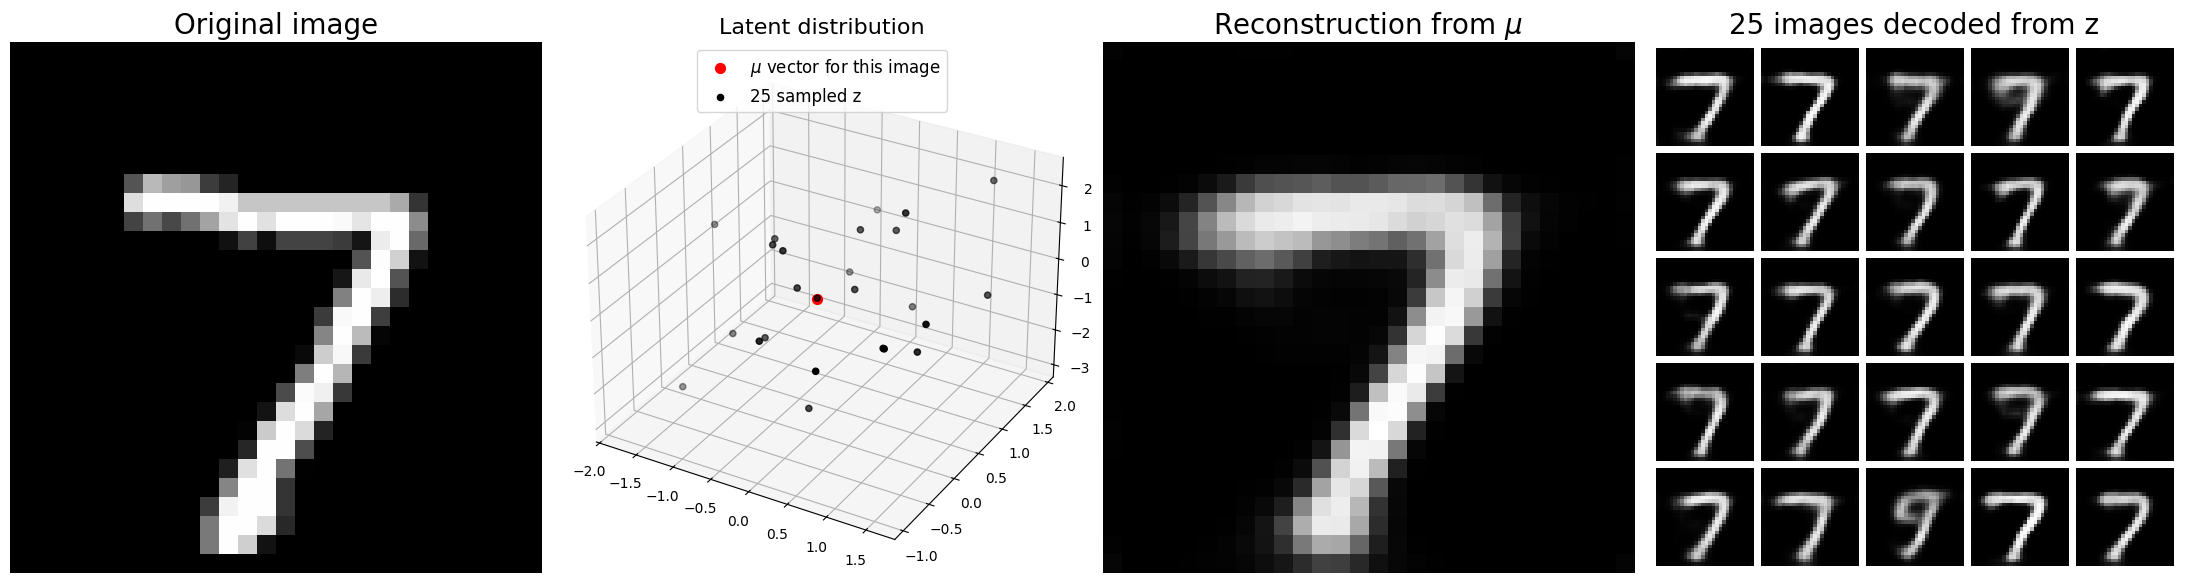

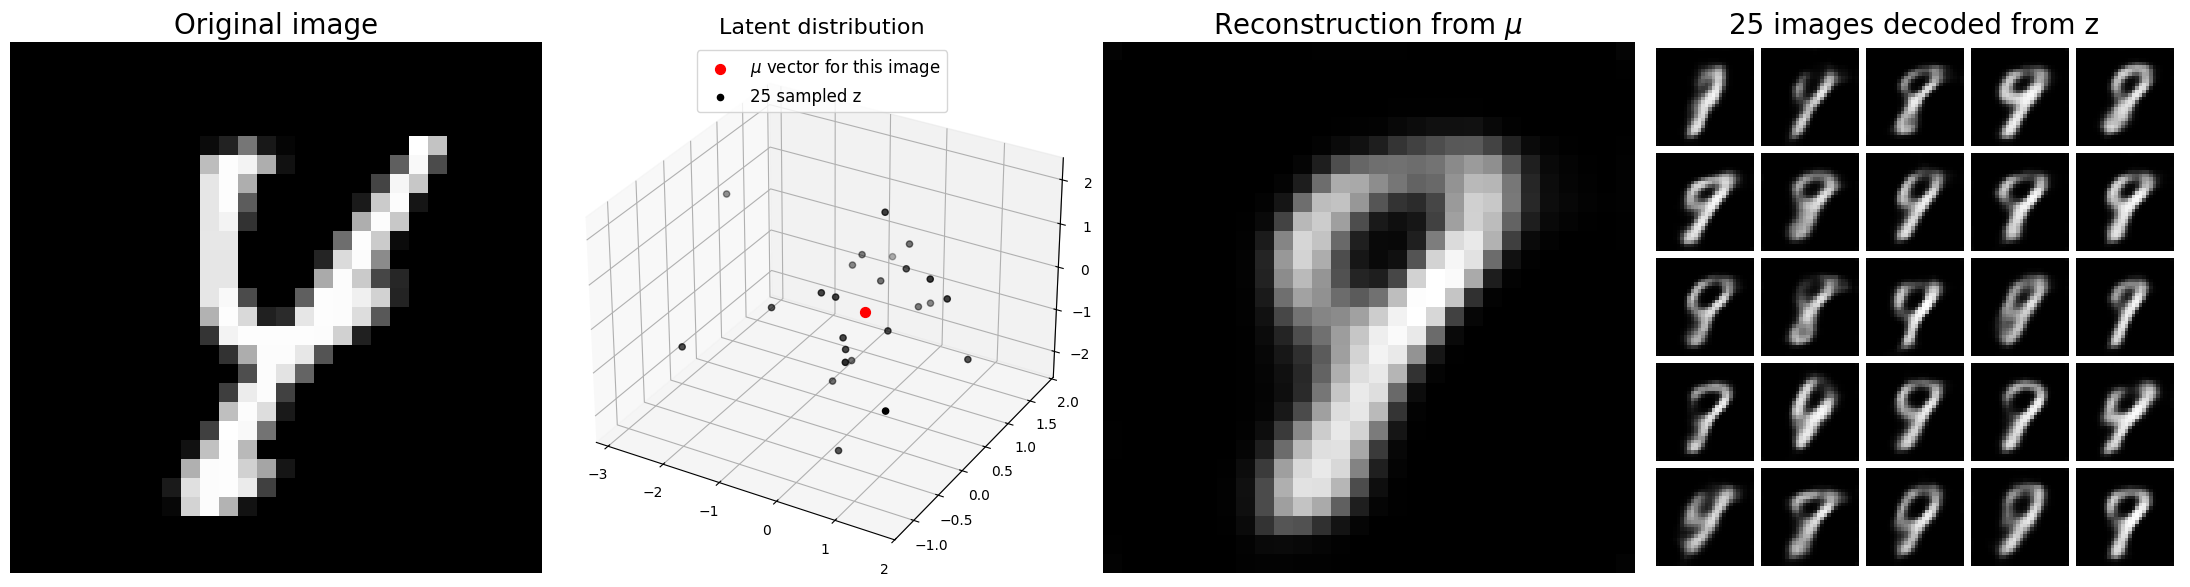

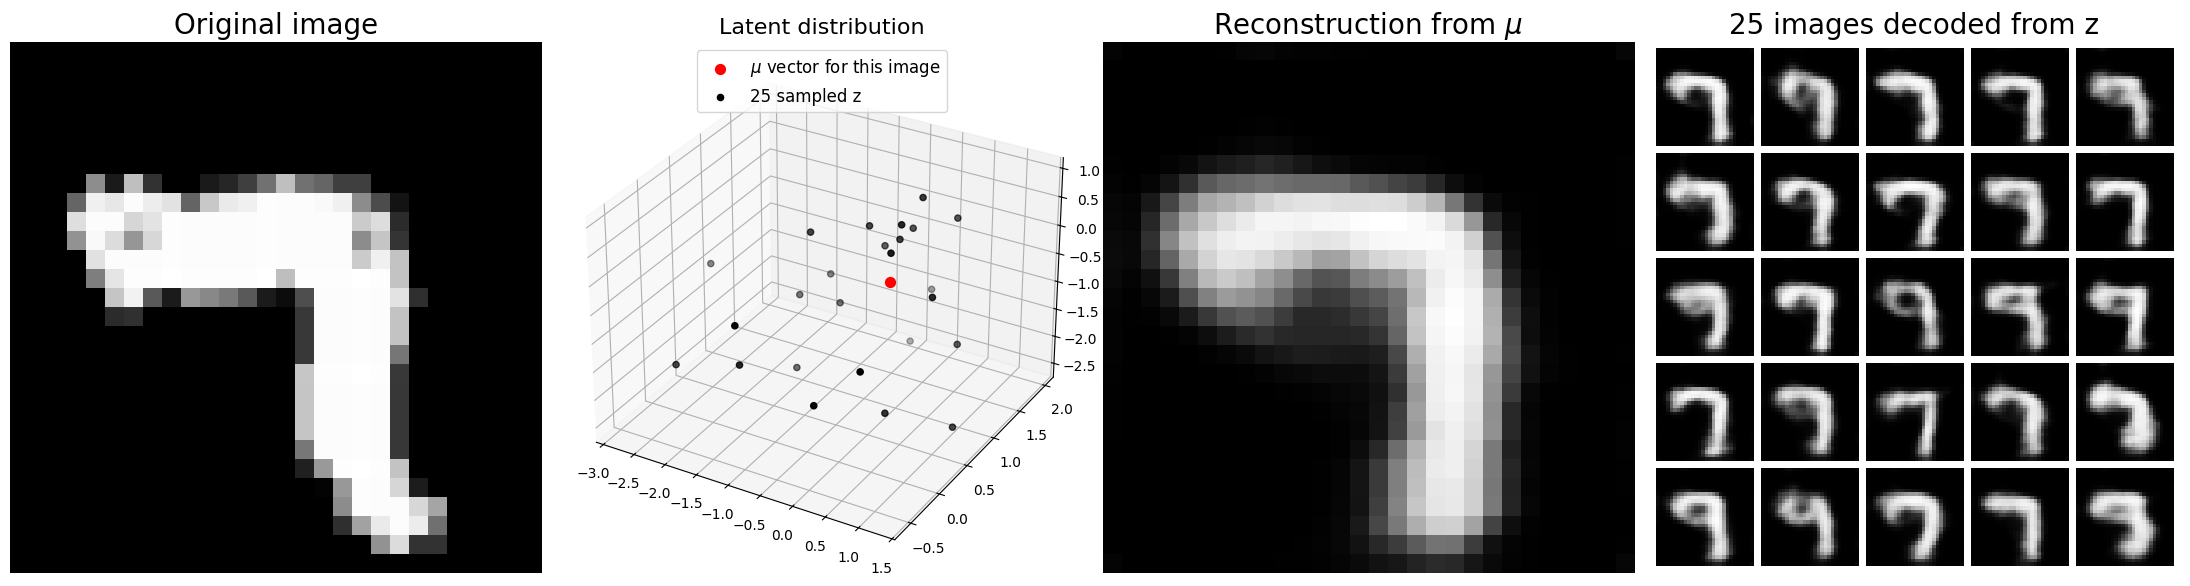

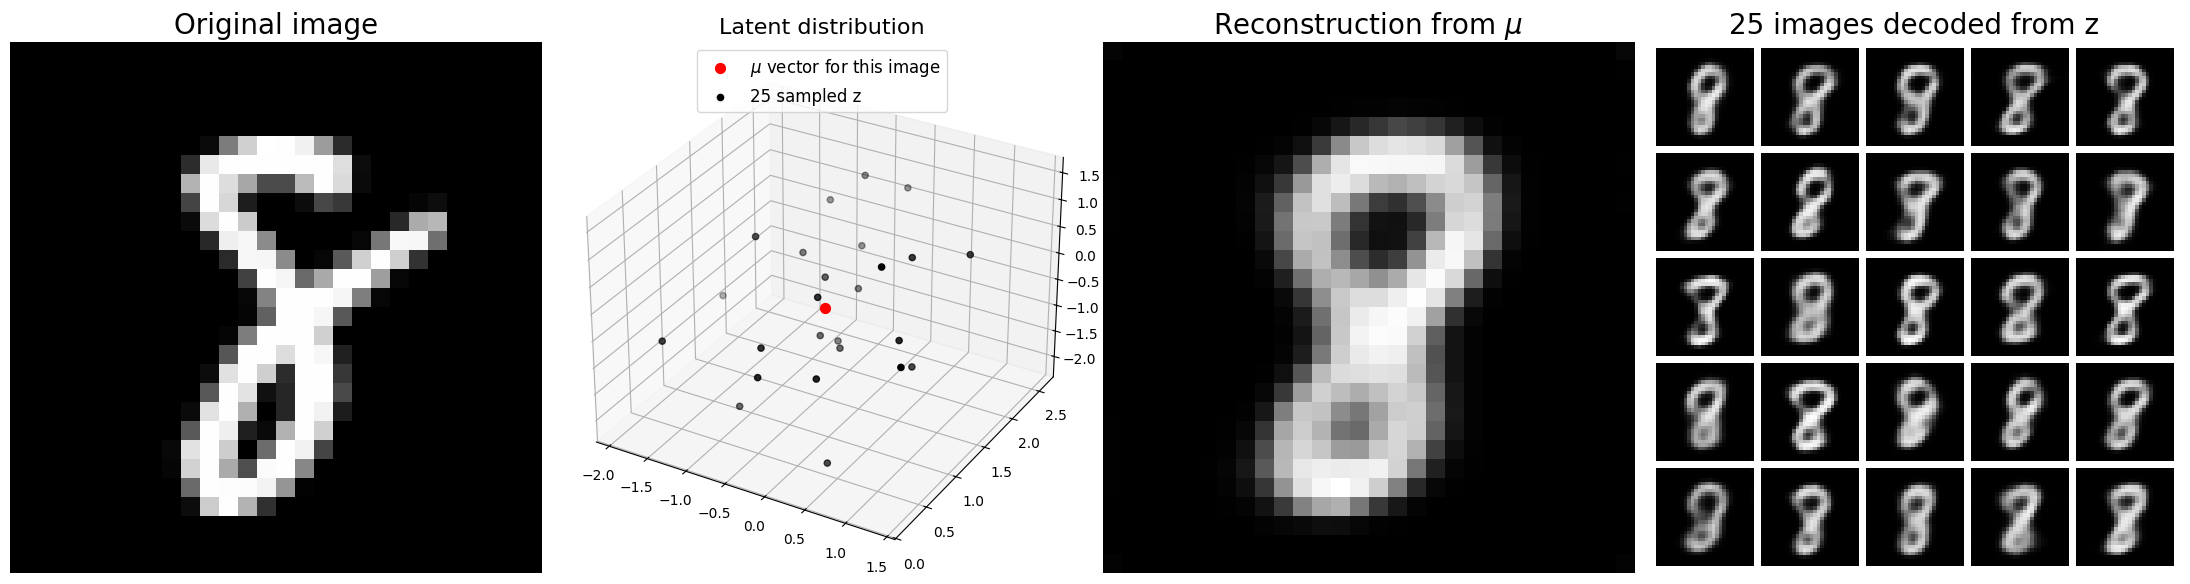

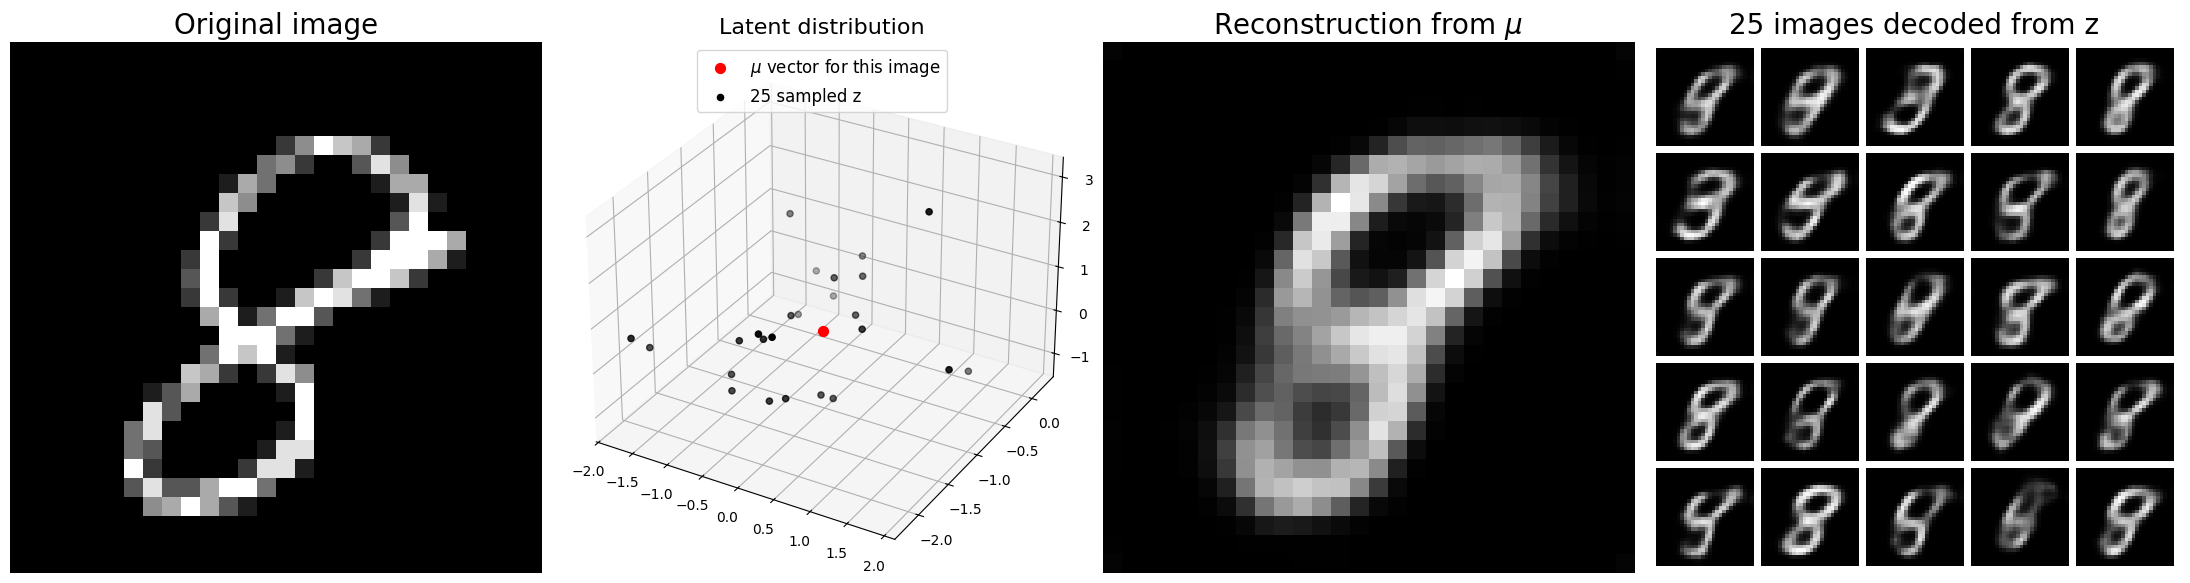

In [144]:
# Show examples
for i, (img, _) in enumerate(test_dataloader):
    if i >= 5:
        break
    show_vae_example(img[0], encoder, decoder, n=5)

## **Fixing Posterior Collapse**

If you observe **posterior collapse**-i.e., the KL loss becomes zero-follow the hints below and retrain the VAE, for example using **KL annealing**.

### **Why Posterior Collapse Happens**

- **KL divergence dominates**
    
    When the KL term is too strong, it forces the latent distribution too close to the prior (standard normal), which reduces the amount of meaningful information encoded in the latent variables.
    
- **Decoder overpowers the encoder**
    
    If the decoder is too expressive, it may learn to reconstruct the input without relying on the latent representation at all.
    
- **Poorly chosen hyperparameters**
    
    An imbalance between the reconstruction loss and KL loss-for instance, a KL weight that is too high early in training-can cause the latent space to collapse.
    
### **How to Prevent Posterior Collapse**

- **KL annealing**
    
    Gradually increase the weight of the KL term during training to allow the latent variables to encode meaningful information first.
    
- **$\beta$-VAE**
    
    Use a smaller KL weight ($\beta < 1$) to reduce excessive regularization of the latent space.
    
- **Adjust encoder/decoder capacity**
    
    Make the encoder strong enough to extract meaningful features, and avoid making the decoder so powerful that it ignores the latent code.

# **Real-NVP for Latent Space**

The introduction already motivated why reconstruction-focused VAE training can skew the latent distribution and why a **Real-NVP** flow is useful to map base samples $u \sim \mathcal{N}(0, I_d)$ to latents $z$ that better match the trained aggregate posterior $q_\phi(z)$. Here you build that flow and train it on latents from the frozen VAE encoder.

Before training the flow, implement a **helper function for sampling** from the latent distribution.

---

### **References / Further Reading**

- Dinh, L., Sohl-Dickstein, J., & Bengio, S. (2017). [_Density Estimation using Real NVP_](https://arxiv.org/abs/1605.08803)
    
- Kingma, D. P., & Dhariwal, P. (2018). [_Glow: Generative Flow with Invertible 1x1 Convolutions_](https://arxiv.org/abs/1710.02248)
    
- Huang, C.-W., Touati, A., Dinh, L., Drozdzal, M., & Havaei, M. (2020). [_Learnable Explicit Density for Continuous Latent Space and Variational Inference_](https://arxiv.org/abs/2006.07733)
    
- Kingma, D. P., & Welling, M. (2013). [_Auto-Encoding Variational Bayes_](https://arxiv.org/abs/1312.6114)


In [145]:
# This is helper class
class Flow(nn.Module, ABC):
    """
    Generic class for flow functions
    """

    def __init__(self) -> None:
        super().__init__()

    @abstractmethod
    def forward(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Args:
          z: input variable, first dimension is batch dim

        Returns:
          transformed z and log of absolute determinant
        """
        raise NotImplementedError("Forward pass has not been implemented.")

    @abstractmethod
    def inverse(self, z: torch.Tensor) -> None:
        raise NotImplementedError("This flow has no algebraic inverse.")

## Normalizing flow base class

Next, we will implement the base class for **NormalizingFlow** that will make up our normalizing flow model.

In [146]:
class NormalizingFlow(nn.Module):
    """
    Normalizing Flow model to approximate target distribution
    """

    def __init__(self, q0: MultivariateNormal, flows: list[Flow]):
        """Constructor

        Args:
          q0: Base distribution
          flows: List of flows
          p: Target distribution
        """
        super().__init__()
        self.q0 = q0
        self.flows = nn.ModuleList(flows)

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        """Transforms latent variable z to the flow variable x

        Args:
          z: Batch in the latent space

        Returns:
          Batch in the space of the target distribution
        """
        for flow in self.flows:
            z, _ = flow(z)
        return z

    def inverse(self, x: torch.Tensor) -> torch.Tensor:
        """Transforms flow variable x to the latent variable z

        Args:
          x: Batch in the space of the target distribution

        Returns:
          Batch in the latent space
        """
        for i in range(len(self.flows) - 1, -1, -1):
            x, _ = self.flows[i].inverse(x)
        return x

    def log_prob(self, x: torch.Tensor) -> torch.Tensor:
        """Get log probability for batch

        Args:
          x: Batch

        Returns:
          log probability
        """
        # TODO: NormalizingFlow.log_prob - inverse map to base z, sum log |det J| from inverses, add log q0(z).
        log_q = torch.zeros(len(x), dtype=x.dtype, device=x.device)
        z = x
        for i in range(len(self.flows) - 1, -1, -1):
            z, log_det = self.flows[i].inverse(z)
            log_q += log_det
        log_q += self.q0.log_prob(z)
        return log_q

    def save(self, path: str) -> None:
        """Save state dict of model

        Args:
          path: Path including filename where to save model
        """
        torch.save(self.state_dict(), path)

    def load(self, path: str):
        """Load model from state dict

        Args:
          path: Path including filename where to load model from
        """
        self.load_state_dict(torch.load(path))


## Split and merge layers

In this step, you will implement the **Split** and **Merge** layer classes, `Split` and `Merge`, respectively.  

The **Split layer** is used in normalizing flows to factor out part of the latent variables at each step.  
This allows the model to capture complex distributions while keeping computations efficient.  

Your task is to implement:

- The **forward transformation** for splitting features and returning the log-determinant of the Jacobian.
- The **inverse transformation** for merging the split features back together, also returning the log-determinant.
- The **Merge layer**, which performs the forward and inverse operations of `Split` in reverse.

In [147]:
class Split(Flow):
    """
    Split features into two sets
    """

    def __init__(self, mode: str = "channel"):
        """Constructor

        The splitting mode can be:

        - channel: Splits first feature dimension, usually channels, into two halves
        - channel_inv: Same as channel, but with z1 and z2 flipped

        Args:
         mode: splitting mode
        """
        super().__init__()
        self.mode = mode

    # TODO: Split - forward splits channels (channel / channel_inv); inverse concatenates halves; log_det 0. Merge delegates to Split.

    def forward(self, z: torch.Tensor) -> tuple[tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        if self.mode == "channel":
            z1, z2 = z[:, : z.shape[1] // 2], z[:, z.shape[1] // 2 :]
        elif self.mode == "channel_inv":
            z2, z1 = z[:, : z.shape[1] // 2], z[:, z.shape[1] // 2 :]
        else:
            raise NotImplementedError("Mode " + self.mode + " is not implemented.")
        log_det = torch.zeros(z.shape[0], dtype=z.dtype, device=z.device)
        return (z1, z2), log_det

    def inverse(self, z: tuple[torch.Tensor, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
        z1, z2 = z
        if self.mode == "channel":
            z = torch.cat([z1, z2], dim=1)
        elif self.mode == "channel_inv":
            z = torch.cat([z2, z1], dim=1)
        else:
            raise NotImplementedError("Mode " + self.mode + " is not implemented.")
        log_det = 0
        return z, log_det


class Merge(Split):
    """
    Same as Split but with forward and backward pass interchanged
    """

    def __init__(self, mode: str = "channel") -> None:
        super().__init__(mode)

    def forward(self, z: tuple[torch.Tensor, torch.Tensor]) -> tuple[torch.Tensor, torch.Tensor]:
        return super().inverse(z)

    def inverse(self, z: torch.Tensor) -> tuple[tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        return super().forward(z)


## Swap layer

In this step, you will implement the **`Swap`** class, which is a **permutation layer** used in normalizing flows.  

The main purpose of this layer is to **reorder the channels** of a feature tensor to increase the expressiveness of the flow. By permuting channels, we allow subsequent transformations to act on different parts of the latent vector, which helps in **mixing information** across channels and modeling complex distributions more effectively.  

In [148]:
class Swap(Flow):
    """
    Permutation features along the channel dimension
    """

    def __init__(self, num_channels: int):
        """Constructor

        Args:
          num_channel: Number of channels
        """
        super().__init__()
        self.num_channels = num_channels

    def forward(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        # TODO: Swap - exchange first/second channel halves forward and inverse (volume-preserving; log_det batch of zeros).
        z1 = z[:, : self.num_channels // 2]
        z2 = z[:, self.num_channels // 2 :]

        z = torch.cat([z2, z1], dim=1)
        log_det = torch.zeros(z.shape[0], dtype=z.dtype, device=z.device)

        return z, log_det

    def inverse(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        z1 = z[:, : self.num_channels // 2]
        z2 = z[:, self.num_channels // 2 :]

        z = torch.cat([z2, z1], dim=1)
        log_det = torch.zeros(z.shape[0], dtype=z.dtype, device=z.device)

        return z, log_det


## Affine coupling layer

In this task you implement AffineCoupling class and construct everything into AffineCouplingBlock.

In [149]:
class AffineCoupling(Flow):
    """
    Affine Coupling layer as introduced RealNVP paper, see arXiv: https://arxiv.org/pdf/1605.08803
    """

    def __init__(self, param_map: nn.Module):
        """Constructor

        Args:
          param_map: Maps features to shift and scale parameter
        """
        super().__init__()
        self.add_module("param_map", param_map)

    def forward(self, z: tuple[torch.Tensor, torch.Tensor]) -> tuple[tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        """
        z is a tuple of z1 and z2; ```z = (z1, z2)```
        z1 is left constant and affine map is applied to z2 with parameters depending
        on z1

        Args:
          z
        """
        # TODO: AffineCoupling - RealNVP affine on z2 from param_map(z1); return log_det summed over non-batch dims.
        z1, z2 = z
        param = self.param_map(z1)
        shift = param[:, 0::2, ...]
        scale_ = param[:, 1::2, ...]

        z2 = z2 * torch.exp(scale_) + shift
        log_det = torch.sum(scale_, dim=list(range(1, scale_.dim())))

        return (z1, z2), log_det

    def inverse(self, z: torch.Tensor) -> tuple[tuple[torch.Tensor, torch.Tensor], torch.Tensor]:
        z1, z2 = z
        param = self.param_map(z1)
        shift = param[:, 0::2, ...]
        scale_ = param[:, 1::2, ...]

        z2 = (z2 - shift) * torch.exp(-scale_)
        log_det = -torch.sum(scale_, dim=list(range(1, scale_.dim())))

        return (z1, z2), log_det


In [150]:
class AffineCouplingBlock(Flow):
    """
    Affine Coupling layer including split and merge operation
    """

    def __init__(self, param_map: nn.Module, split_mode: str = "channel"):
        """Constructor

        Args:
          param_map: Maps features to shift and scale parameter (if applicable)
          split_mode: Splitting mode, for possible values see Split class
        """
        super().__init__()
        self.flows = nn.ModuleList([])
        # TODO: AffineCouplingBlock - chain Split -> AffineCoupling -> Merge; forward/inverse with summed log dets.
        self.flows += [Split(split_mode)]
        self.flows += [AffineCoupling(param_map)]
        self.flows += [Merge(split_mode)]

    def forward(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        log_det_tot = torch.zeros(z.shape[0], dtype=z.dtype, device=z.device)
        for flow in self.flows:
            z, log_det = flow.forward(z)
            log_det_tot += log_det
        return z, log_det_tot

    def inverse(self, z: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        log_det_tot = torch.zeros(z.shape[0], dtype=z.dtype, device=z.device)
        for flow in reversed(self.flows):
            z, log_det = flow.inverse(z)
            log_det_tot += log_det
        return z, log_det_tot


## Training the Real-NVP

In this task, you will assemble the **Real-NVP normalizing flow** by combining the layers you implemented (Split, Merge, Swap, AffineCoupling, etc.).  

Your goals are:

1. **Build the flow**  
   - Stack multiple **Affine Coupling blocks** with appropriate permutations or swaps between them.  
   - Define a base distribution (usually a standard Gaussian) for sampling latent variables.

2. **Implement the loss function**  
  - Use **maximum likelihood** to train the flow:  
$$
\mathcal{L}_{\text{Real-NVP}}
= - \sum_i \underbrace{\log {\color{red}{p_X(x_i)}}}_{\text{target latent log-probability}}
= - \sum_i \Big( \underbrace{\log {\color{purple}{p_Z}}(z_i)}_{\text{base Gaussian log-prob}}
+ \underbrace{\sum_{k} {\color{blue}{\log |\det J_k|}}}_{\text{log-det of each transformation}} \Big)
$$

3. **Train the Real-NVP**  
   - Sample $z \sim {\color{purple}{p_Z}}(z)$ from the base Gaussian and transform through the flow.  
   - Optimize the log-probability of the **target latent vectors** obtained from the VAE.

> **Hint:** This flow learns a mapping from the simple Gaussian to the complex aggregated posterior of VAE latents, allowing for higher-quality sampling.

In [151]:
class MLP(nn.Module):
    """
    A multilayer perceptron with Leaky ReLU nonlinearities
    """

    def __init__(
        self,
        layers: list[int],
        leaky: float = 0.0,
        init_zeros: bool = False,
        dropout: float | None = None,
    ):
        """
        layers: list of layer sizes from start to end
        leaky: slope of the leaky part of the ReLU, if 0.0, standard ReLU is used
        init_zeros: Flag, if true, weights and biases of last layer are initialized with zeros (helpful for deep models, see [arXiv 1807.03039](https://arxiv.org/abs/1807.03039))
        dropout: Float, if specified, dropout is done before last layer; if None, no dropout is done
        """
        super().__init__()
        net = nn.ModuleList([])
        for k in range(len(layers) - 2):
            net.append(nn.Linear(layers[k], layers[k + 1]))
            net.append(nn.LeakyReLU(leaky))

        if dropout is not None:
            net.append(nn.Dropout(p=dropout))
        net.append(nn.Linear(layers[-2], layers[-1]))
        if init_zeros:
            nn.init.zeros_(net[-1].weight)
            nn.init.zeros_(net[-1].bias)
        self.net = nn.Sequential(*net)

    def forward(self, x):
        return self.net(x)

In [171]:
# ---------------------------
# Define Gaussian base distribution
# ---------------------------
# Initialize the base distribution q0 as a standard Gaussian
# This serves as the simple distribution that the flow will transform
loc = torch.zeros(LATENT_DIM, device=DEVICE)
scale = torch.ones(LATENT_DIM, device=DEVICE)
q0 = MultivariateNormal(loc=loc, scale_tril=torch.diag(scale))

# ---------------------------
# Define list of flows
# ---------------------------
num_layers = 32
flows = []
for i in range(num_layers):
    # Define the neural network that maps half of the features to shift and scale
    #       - Use hidden layers with 64 units each
    #       - Initialize last layer with zeros for stable training
    param_map = MLP([LATENT_DIM // 2, LATENT_DIM * 2, LATENT_DIM], init_zeros=True)

    # Add an affine coupling block using the param_map
    flows.append(AffineCouplingBlock(param_map))

    # Add a Swap layer to permute channels and increase expressiveness
    flows.append(Swap(LATENT_DIM))

flow_model = NormalizingFlow(q0, flows).to(DEVICE)

In [172]:
# Choose hyperparameters for optimizer
FLOW_OPTIM_LR = 1e-3 # choose very small learning rate
WEIGHT_DECAY = 1e-5
FLOW_NUM_EPOCHS = 50

flow_optimizer = torch.optim.Adam(flow_model.parameters(), lr=FLOW_OPTIM_LR, weight_decay=WEIGHT_DECAY)

In [173]:
def train_flow_on_latents(
    flow_model: Flow,
    vae: VAE,
    dataloader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: str = DEVICE,
    max_epochs: int = FLOW_NUM_EPOCHS,
):
    """
    Train a normalizing flow on the latent space of a pretrained VAE.

    Args:
        flow_model: Normalizing flow model
        vae: Pretrained VAE
        dataloader: DataLoader for original dataset
        optimizer: optimizer for the flow
        device: torch device
        max_epochs: number of epochs
    """
    flow_model.train()
    vae.eval()
    for p in vae.parameters():
        p.requires_grad = False

    for epoch in range(max_epochs):
        total_nll = 0.0  # negative log-likelihood
        n_batches = 0

        for x, _ in dataloader:
            x = x.to(device)

            # TODO: train_flow_on_latents - encode with frozen VAE; minimize -mean(flow.log_prob(z)).
            with torch.no_grad():
                _, _, z_batch = vae.encoder(x)

            optimizer.zero_grad()
            nll = -flow_model.log_prob(z_batch).mean()

            if torch.isfinite(nll):
                nll.backward()
                optimizer.step()

            total_nll += nll.item()
            n_batches += 1

        avg_nll = total_nll / n_batches
        print(f"Epoch [{epoch+1}/{max_epochs}] | " f"Avg Flow NLL: {avg_nll:.4f}")


In [174]:
train_flow_on_latents(flow_model, vae, train_dataloader, flow_optimizer)

Epoch [1/50] | Avg Flow NLL: 91.8205
Epoch [2/50] | Avg Flow NLL: 90.9823
Epoch [3/50] | Avg Flow NLL: 90.8961
Epoch [4/50] | Avg Flow NLL: 90.8333
Epoch [5/50] | Avg Flow NLL: 90.7622
Epoch [6/50] | Avg Flow NLL: 90.7038
Epoch [7/50] | Avg Flow NLL: 90.6501
Epoch [8/50] | Avg Flow NLL: 90.5994
Epoch [9/50] | Avg Flow NLL: 90.5714
Epoch [10/50] | Avg Flow NLL: 90.5691
Epoch [11/50] | Avg Flow NLL: 90.5026
Epoch [12/50] | Avg Flow NLL: 90.4770
Epoch [13/50] | Avg Flow NLL: 90.4640
Epoch [14/50] | Avg Flow NLL: 90.4377
Epoch [15/50] | Avg Flow NLL: 90.4419
Epoch [16/50] | Avg Flow NLL: 90.4592
Epoch [17/50] | Avg Flow NLL: 90.3844
Epoch [18/50] | Avg Flow NLL: 90.3878
Epoch [19/50] | Avg Flow NLL: 90.3866
Epoch [20/50] | Avg Flow NLL: 90.3459
Epoch [21/50] | Avg Flow NLL: 90.3384
Epoch [22/50] | Avg Flow NLL: 90.3343
Epoch [23/50] | Avg Flow NLL: 90.3679
Epoch [24/50] | Avg Flow NLL: 90.2974
Epoch [25/50] | Avg Flow NLL: 90.3252
Epoch [26/50] | Avg Flow NLL: 90.2836
Epoch [27/50] | Avg F

## Latent space visualization

In this task, you will extract the latent vectors from a pretrained VAE and visualize how they are transformed by a normalizing flow.

Specifically, you should:

1. Encode data points into the VAE latent space to obtain latent vectors.
    
2. Apply the normalizing flow to map these latent vectors to the base distribution.

In [175]:
def show_latent_space_with_flow(
    encoder: Encoder,
    flow_model: Flow,
    test_loader: DataLoader,
    device: str = DEVICE,
):
    """
    Visualizes VAE posterior latent samples z before and after applying the inverse flow
    to map them to base Gaussian space.
    """
    encoder.eval()
    flow_model.eval()

    all_z = []
    all_u = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)

            # TODO: show_latent_space_with_flow - collect per-batch z (posterior samples) and u = flow.inverse(z); append for plotting.
            _, _, z_batch = encoder(images)
            u = flow_model.inverse(z_batch)

            all_z.append(z_batch.cpu())
            all_u.append(u.cpu())
            all_labels.append(labels.cpu())

    z_np = torch.cat(all_z, dim=0).numpy()
    u_np = torch.cat(all_u, dim=0).numpy()
    labels_np = torch.cat(all_labels, dim=0).numpy()

    def plot_3d(data, title):
        fig = plt.figure(figsize=(8, 8))
        ax = plt.axes(projection="3d")
        ax.set_title(title)

        if data.shape[1] > 3:
            pca = PCA(n_components=3)
            data_3d = pca.fit_transform(data)
        else:
            data_3d = data

        scatter = ax.scatter(
            data_3d[:, 0],
            data_3d[:, 1],
            data_3d[:, 2],
            c=labels_np,
            cmap="tab10",
            alpha=0.6,
        )
        fig.colorbar(scatter)
        plt.show()

    plot_3d(z_np, r"Latent samples $z$ (posterior) before inverse flow")
    plot_3d(u_np, r"Latent samples after $f^{-1}(z)$ (base Gaussian space)")


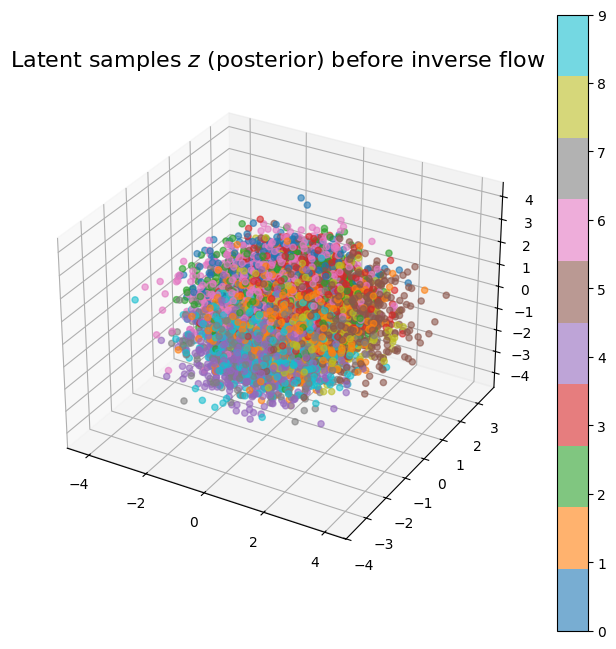

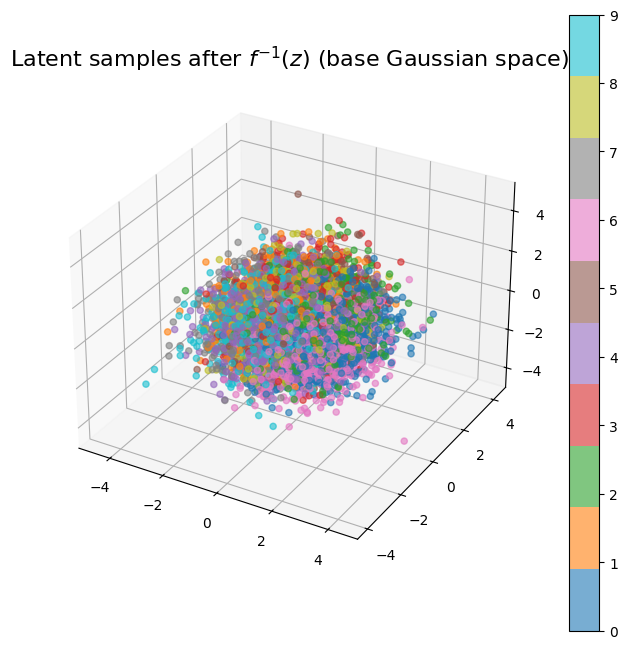

In [176]:
show_latent_space_with_flow(vae.encoder, flow_model, test_dataloader)

## Latent space mapping and flow visualization

This task visualizes the transformation between an image, its **VAE posterior samples** z, and their mapping into a simplified **Gaussian base space** u via a Normalizing Flow. By decoding these latent points, we can observe the structural "shift" and diversity of the model's generative manifold.

In [177]:
def show_vae_with_flow(
    image: torch.Tensor,
    encoder: Encoder,
    decoder: Decoder,
    flow_model: Flow,
    n: int = 5,
    device: torch.device = DEVICE,
):
    """
    Visualizes a single image, its latent distribution, reconstruction,
    posterior samples, and optionally transformed latent samples through a flow.

    Args:
        image: Tensor (C,H,W) or (1,C,H,W)
        encoder: Trained VAE encoder
        decoder: Trained VAE decoder
        flow_model: Normalizing flow trained on latent space
        n: Grid size for posterior samples (n x n)
        device: Device for computation
    """
    encoder.eval()
    decoder.eval()
    flow_model.eval()

    if image.ndim == 3:
        image = image.unsqueeze(0)

    image = image.to(device).float()
    latent_dim = encoder.mu_layer.out_features
    num_samples = n * n

    # ----------------------------
    # Encode image
    # ----------------------------
    with torch.no_grad():
        # TODO: show_vae_with_flow - posterior samples z ~ N(mu, sigma^2), u = flow.inverse(z_samples), recon from mu.
        mu, logvar, _ = encoder(image)
        sigma = torch.exp(0.5 * logvar)

        eps = torch.randn(num_samples, latent_dim, device=device)
        z_samples = mu + sigma * eps

        u_samples = flow_model.inverse(z_samples)

    # ----------------------------
    # Generate images from posterior samples
    # ----------------------------
    recon = decoder(mu)
    generated_images = decoder(z_samples).cpu()  # (N,C,H,W)
    generated_images_grid = make_grid(generated_images, nrow=n, normalize=True, pad_value=1)
    generated_images_grid = generated_images_grid.permute(1, 2, 0).numpy()  # H,W,C for plt

    # ----------------------------
    # Plotting
    # ----------------------------
    fig = plt.figure(figsize=(22, 7))

    # Original image
    ax = fig.add_subplot(1, 4, 1)
    ax.set_title("Original image", fontsize=18)
    img_to_show = image[0].permute(1, 2, 0).cpu().numpy()
    if img_to_show.shape[-1] == 1:
        img_to_show = img_to_show[..., 0]
    ax.imshow(img_to_show, cmap="gray")
    ax.axis("off")

    # Latent space
    ax = fig.add_subplot(1, 4, 2, projection="3d")
    ax.scatter(mu[0, 0].cpu(), mu[0, 1].cpu(), mu[0, 2].cpu(), color="red", s=50, label=r"$\mu$ from image")
    ax.scatter(
        z_samples[:, 0].cpu(),
        z_samples[:, 1].cpu(),
        z_samples[:, 2].cpu(),
        color="black",
        alpha=0.6,
        label=f"{num_samples} posterior samples z",
    )
    ax.scatter(
        u_samples[:, 0].cpu(),
        u_samples[:, 1].cpu(),
        u_samples[:, 2].cpu(),
        color="blue",
        alpha=0.5,
        label=r"$u$ flow-mapped samples from z",
    )
    ax.legend(loc="upper center", fontsize=12)
    ax.set_title("Latent distribution", fontsize=16)

    # Reconstruction from mu
    ax = fig.add_subplot(1, 4, 3)
    ax.set_title(r"Reconstruction from $\mu$", fontsize=18)
    recon_img = recon[0].permute(1, 2, 0).cpu().numpy()
    if recon_img.shape[-1] == 1:
        recon_img = recon_img[..., 0]
    ax.imshow(recon_img, cmap="gray")
    ax.axis("off")

    # Generated images from posterior
    ax = fig.add_subplot(1, 4, 4)
    ax.set_title(f"{num_samples} posterior samples", fontsize=18)
    ax.imshow(generated_images_grid)
    ax.axis("off")

    plt.tight_layout()
    plt.show()


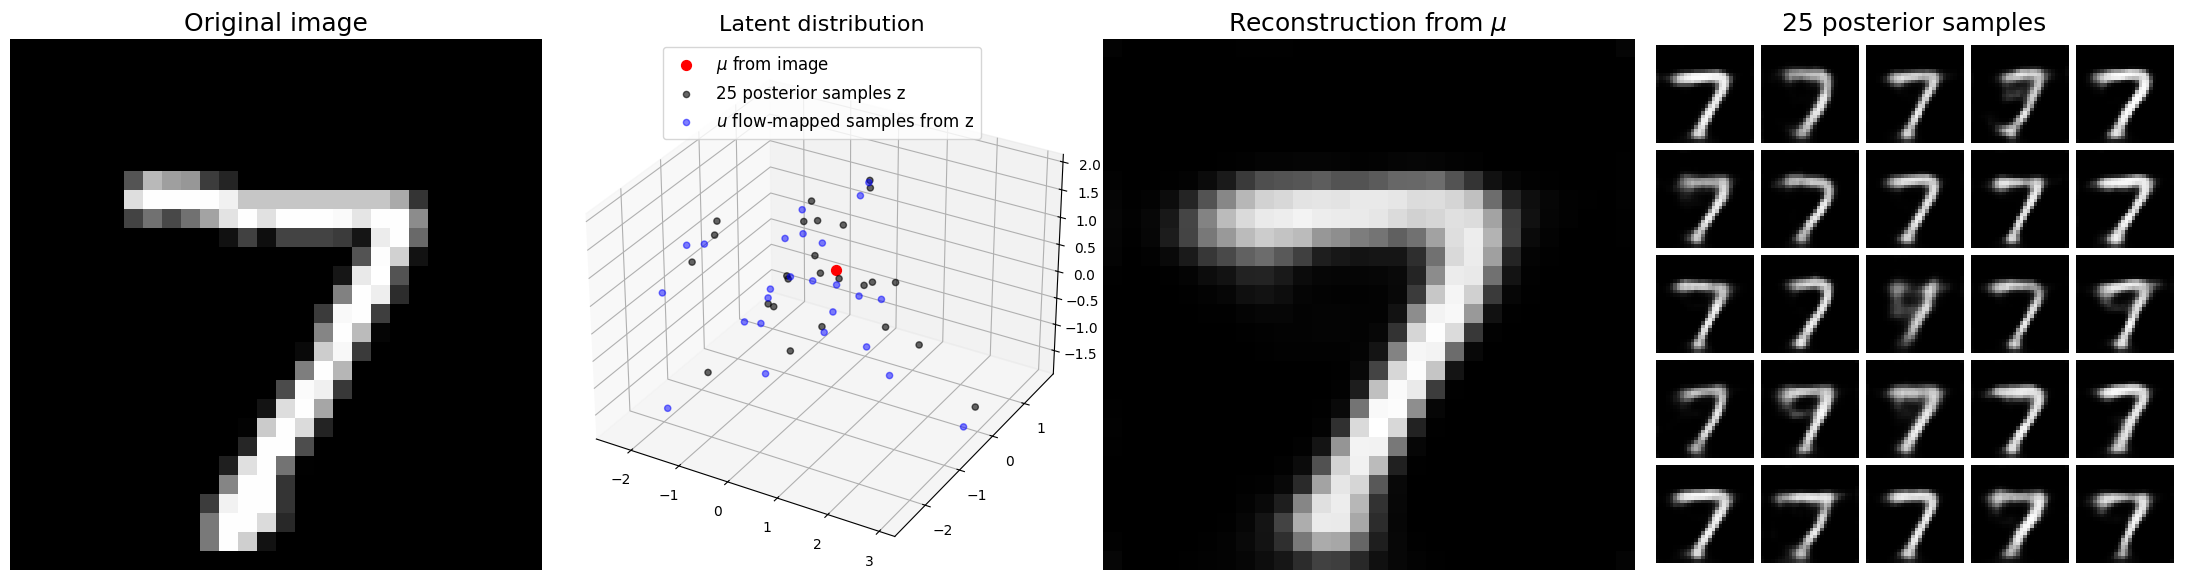

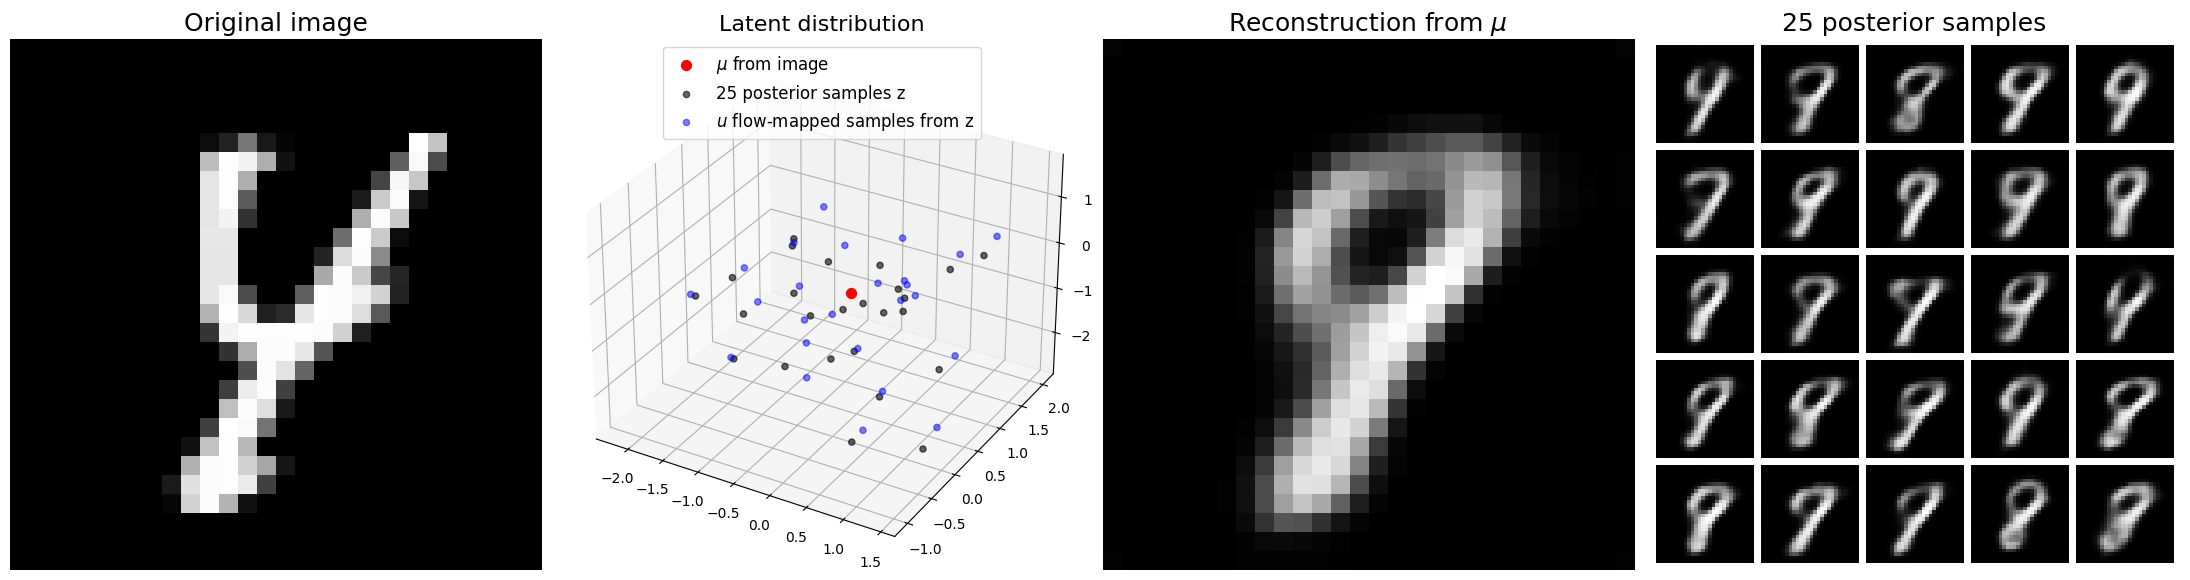

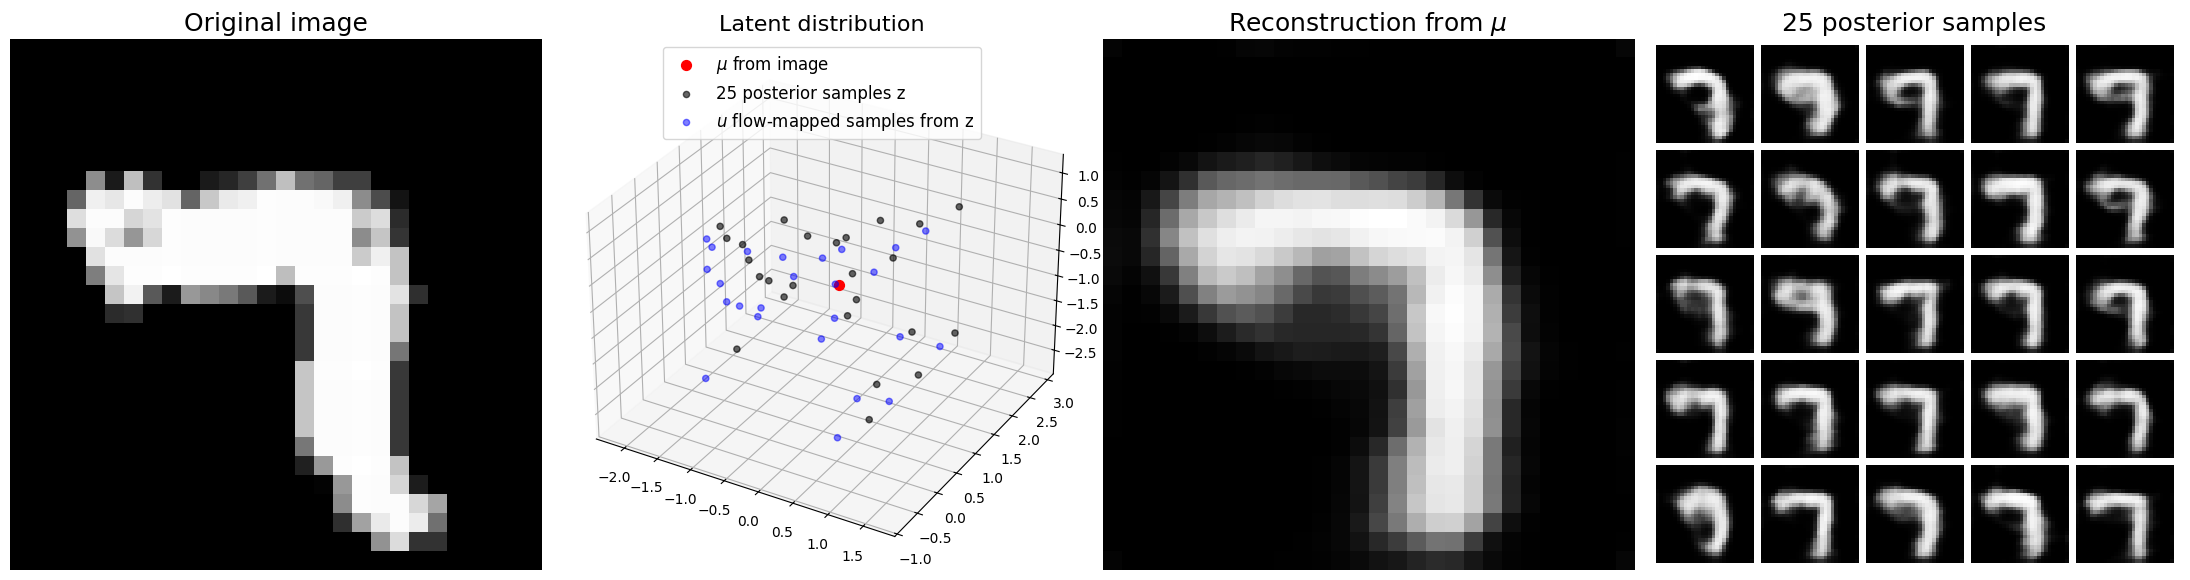

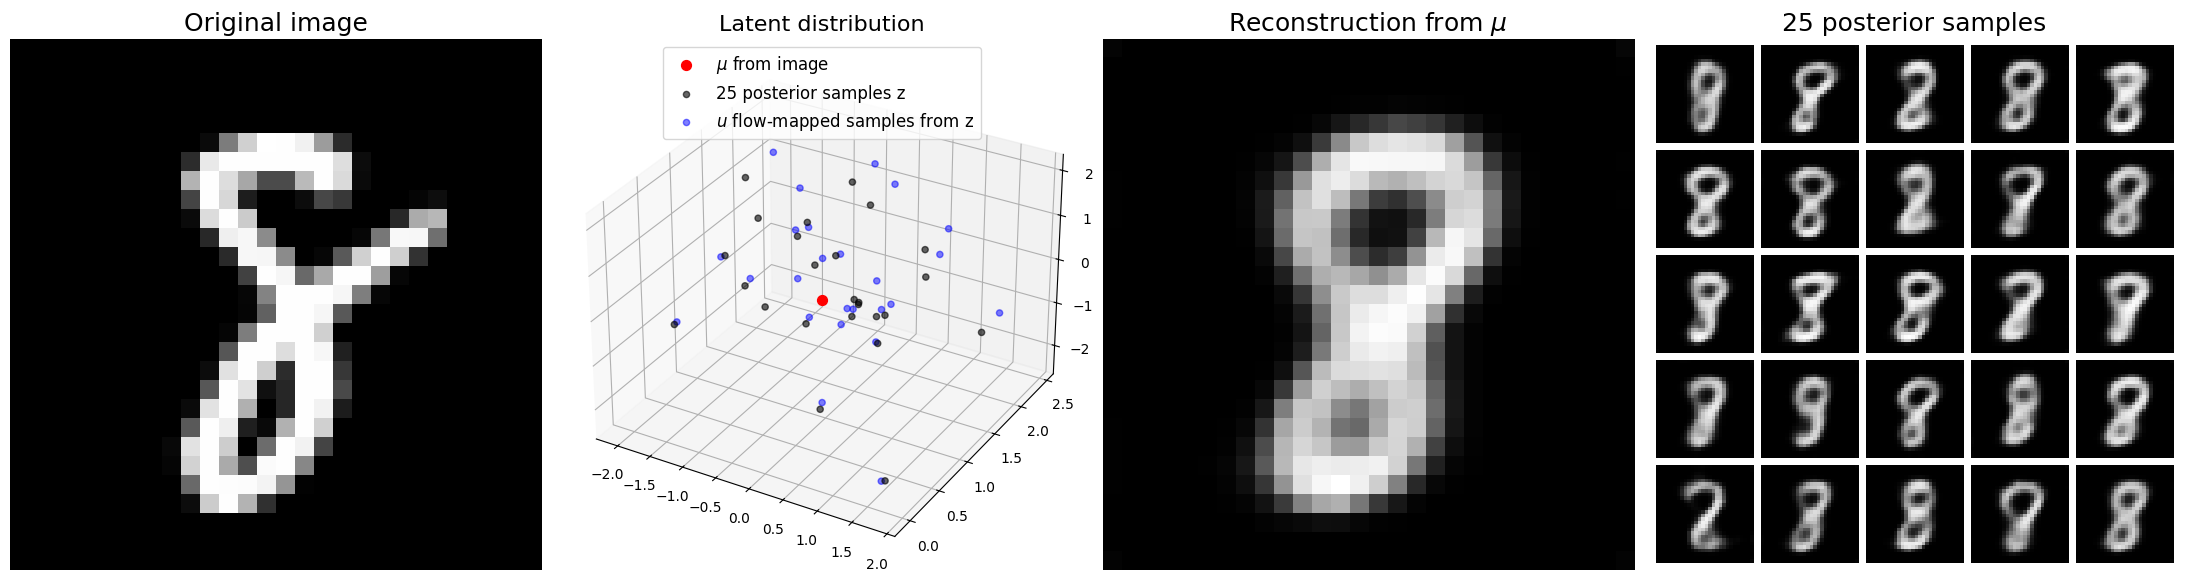

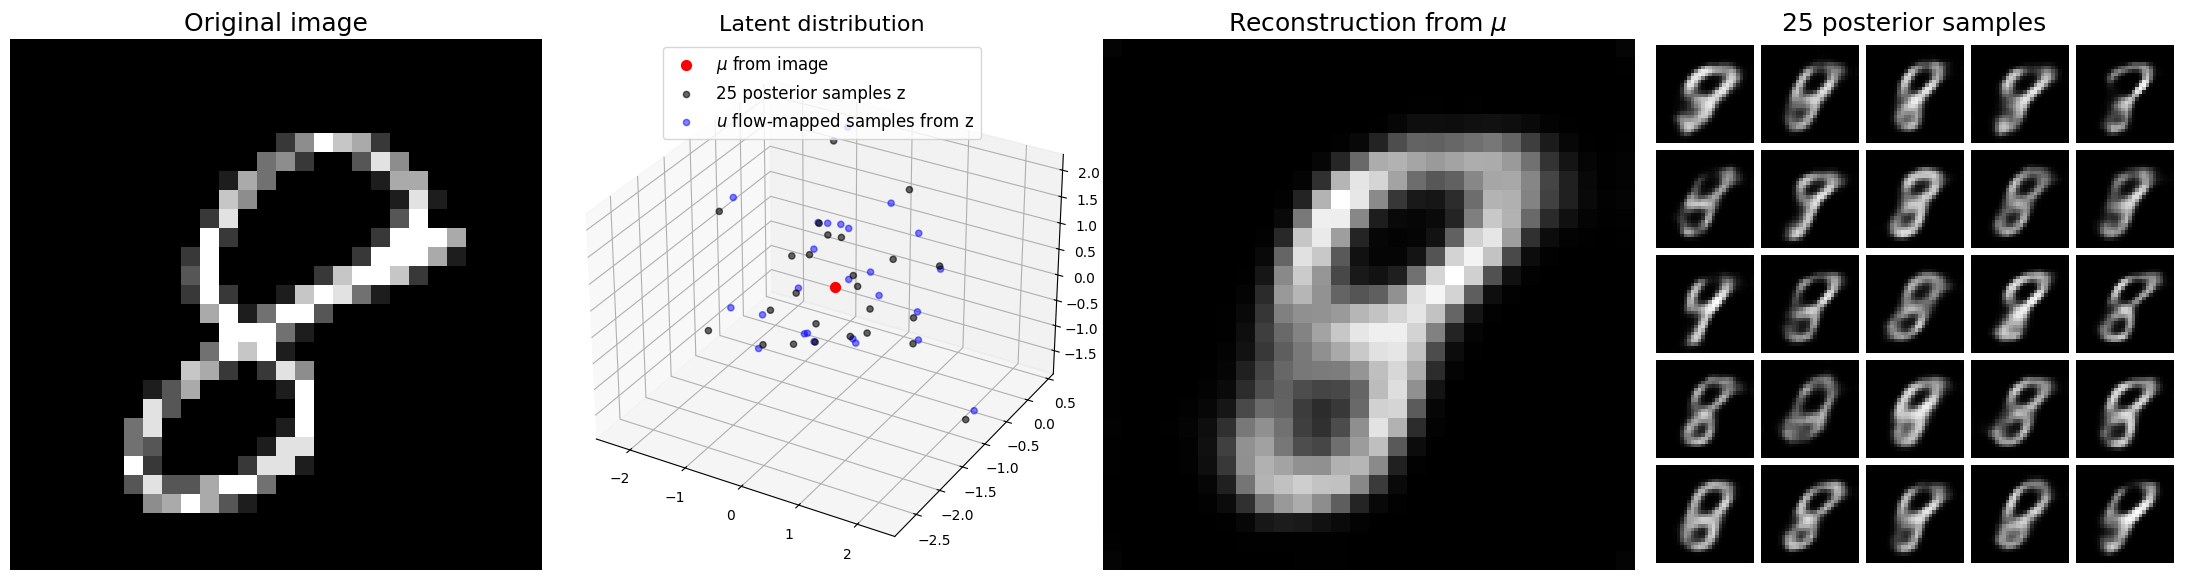

In [178]:
# Show examples
for i, (img, _) in enumerate(test_dataloader):
    if i >= 5:
        break
    show_vae_with_flow(img[0], encoder, decoder, flow_model, n=5, device=DEVICE)

## Latent prior vs. flow-transformed generation

This task compares the generative quality of a standard VAE against one enhanced by a Normalizing Flow. By contrasting samples drawn directly from a Gaussian prior with those refined through the flow's transformation, we visualize how the flow recontorts the latent space to better match the true data distribution.

In [179]:
def compare_z_and_forward_flow_from_prior(
    decoder: Decoder,
    flow_model,
    latent_dim: int,
    n: int = 5,
    device: torch.device = DEVICE
):
    """
    Compare images generated from:
    1) Latent samples z ~ N(0,I)
    2) Forward flow-transformed latent samples u = flow.forward(z)

    Args:
        decoder: Trained VAE decoder
        flow_model: Trained normalizing flow
        latent_dim: Dimensionality of the latent space
        n: Grid size for samples (n x n)
        device: torch device
    """
    decoder.eval()
    flow_model.eval()

    num_samples = n * n

    with torch.no_grad():
        # TODO: compare_z_and_forward_flow_from_prior - z ~ N(0,I), u = flow(z), decode both for side-by-side grids.
        z_samples = torch.randn(num_samples, latent_dim, device=device)

        u_samples = flow_model(z_samples)

        imgs_z = decoder(z_samples)   # (N,C,H,W)
        imgs_u = decoder(u_samples)   # (N,C,H,W)

        # Make grids
        grid_z = make_grid(imgs_z.cpu(), nrow=n, padding=2, pad_value=1, normalize=True)
        grid_u = make_grid(imgs_u.cpu(), nrow=n, padding=2, pad_value=1, normalize=True)

        # Convert to HWC for matplotlib
        grid_z_np = grid_z.permute(1, 2, 0).numpy()
        grid_u_np = grid_u.permute(1, 2, 0).numpy()

        # For grayscale images, remove channel dimension
        if grid_z_np.shape[2] == 1:
            grid_z_np = grid_z_np[..., 0]
        if grid_u_np.shape[2] == 1:
            grid_u_np = grid_u_np[..., 0]

    # ----------------------------
    # Plotting
    # ----------------------------
    _, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(grid_z_np, cmap="gray")
    axes[0].set_title(r"Generation from $z \sim \mathcal{N}(0,I_d)$ (VAE Decoder)")
    axes[0].axis("off")

    axes[1].imshow(grid_u_np, cmap="gray")
    axes[1].set_title(r"Generation from  $u$ ($z$ -> $u$) (Latent RealNVP)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


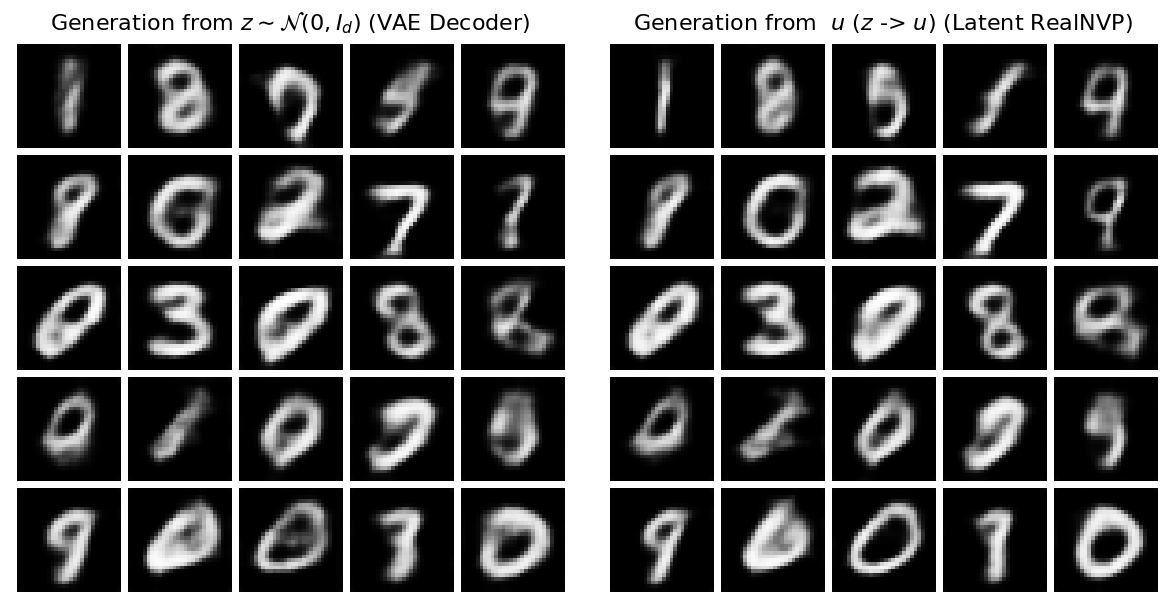

In [180]:
compare_z_and_forward_flow_from_prior(decoder, flow_model, LATENT_DIM)

* We see, that Real-NVP allows for a less blurry generations. It is caused by the fact that Real-NVP maps the standard Gaussian to the latent distribution of the VAE Encoder. Latent distribution of VAE is non-Gaussian due to $\beta=2e-3$ and its Decoder cannot sample good images from standard Gaussian. Real-NVP allows to map the standard Gaussian to the latent distribution of the VAE Encoder, from which VAE Decoder can sample better, less blurry images.

# Conclusion and performance analysis

Summarize your findings from the experiments, focusing on the synergy between **Variational Autoencoders (VAEs)** and **Normalizing Flows**.

### Comments on VAE training & Latent Space:
* By setting $\beta = 2e-3$, the model is allowed to prioritize the reconstruction loss over the prior regularization. This encourages the VAE to learn a good latent space, as seen in the clustered 3D PCA plots. Such low value of $\beta$ allows to avoid posterior collapse.

* Downised of using $\beta = 2e-3$ is that posterior distribution deviates from the standard Gaussian prior. 

* When we try to generate images by sampling randomly from the standard prior $z \sim \mathcal{N}(0, I_d)$ we frequently sample from regions in the latent space, where the VAE has never seen data. Because the decoder doesn't know how to map these empty regions, it outputs blurry digits.

### VAE & Real-NVP Synergy: Why Real-NVP Samples are Less Blurry
* Instead of forcing the VAE's encoder to match a simple Gaussian, which hurts reconstruction, we let the VAE learn whatever complex latent manifold it needs to reconstruct the images perfectly. Then, we train a 32-layer Real-NVP flow to map this complex, learned latent distribution to a true standard Gaussian.

* RealNVP fixes the blurriness problem by mapping the standard Gaussian to the complex latent manifold, from which VAE Decoder can restore sharp images.

* We see, that Real-NVP allows for a less blurry generations. It is caused by the fact that Real-NVP maps the standard Gaussian to the latent distribution of the VAE Encoder. Latent distribution of VAE is non-Gaussian due to $\beta=2e-3$ and its Decoder cannot sample good images from standard Gaussian. Real-NVP allows to map the standard Gaussian to the latent distribution of the VAE Encoder, from which VAE Decoder can sample better, less blurry images.